In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from math import sqrt
import matplotlib.pyplot as plt
import matplotlib.pyplot as pyplot
from matplotlib.collections import LineCollection
import xgboost as xgb
import statistics as stats
import statsmodels.api as sm
import shap
from xgboost import plot_importance, plot_tree, XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split, cross_val_score
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import linear_reset

# *Preprocessing* Data

In [ ]:
# Input Data
data = pd.read_csv('/content/Skripsi_Fellita Odelia Wibowo.csv')
data

,Bulan,Suhu,DPM Rata-rata,DPM Maksimum,DPM Minimum
0,01 1999,24.177419,30092.61419,40613.36,9725.40
1,02 1999,23.971429,33898.16893,40363.34,8823.81
2,03 1999,24.280645,32010.34290,40334.69,1194.58
3,04 1999,24.133333,36139.28767,39600.00,19013.41
4,05 1999,23.590323,38292.59323,39589.61,27711.09
...,...,...,...,...,...
313,02 2025,24.460714,35262.12000,41519.75,12301.87
314,03 2025,24.954839,33148.25742,41275.54,18045.26
315,04 2025,24.763333,35864.13900,39617.05,23049.29
316,05 2025,25.351613,33211.00806,39594.77,18897.02


In [ ]:
# Menyiapkan Data
data = data.set_index('Bulan')
data.index = pd.to_datetime(data.index, format = ' %m %Y')

In [ ]:
# Menampilkan 5 Baris Pertama
print(data.head())

                 Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
Bulan                                                          
1999-01-01  24.177419    30092.61419      40613.36      9725.40
1999-02-01  23.971429    33898.16893      40363.34      8823.81
1999-03-01  24.280645    32010.34290      40334.69      1194.58
1999-04-01  24.133333    36139.28767      39600.00     19013.41
1999-05-01  23.590323    38292.59323      39589.61     27711.09


In [ ]:
# Menampilkan Informasi Data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 318 entries, 1999-01-01 to 2025-06-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suhu           318 non-null    float64
 1   DPM Rata-rata  318 non-null    float64
 2   DPM Maksimum   318 non-null    float64
 3   DPM Minimum    318 non-null    float64
dtypes: float64(4)
memory usage: 12.4 KB
None


In [ ]:
# Mendefinisikan Variabel
Suhu = data['Suhu']
DPM_mean = data['DPM Rata-rata']
DPM_max = data['DPM Maksimum']
DPM_min = data['DPM Minimum']

In [ ]:
# Menyiapkan Data (DPM Rata-rata)
data_mean = data[['DPM Rata-rata']].copy()
print(data_mean.head())

            DPM Rata-rata
Bulan                    
1999-01-01    30092.61419
1999-02-01    33898.16893
1999-03-01    32010.34290
1999-04-01    36139.28767
1999-05-01    38292.59323


In [ ]:
# Menyiapkan Data (DPM Maksimum)
data_max = data[['DPM Maksimum']].copy()
print(data_max.head())

            DPM Maksimum
Bulan                   
1999-01-01      40613.36
1999-02-01      40363.34
1999-03-01      40334.69
1999-04-01      39600.00
1999-05-01      39589.61


In [ ]:
# Menyiapkan Data (DPM Minimum)
data_min = data[['DPM Minimum']].copy()
print(data_min.head())

            DPM Minimum
Bulan                  
1999-01-01      9725.40
1999-02-01      8823.81
1999-03-01      1194.58
1999-04-01     19013.41
1999-05-01     27711.09


# DPM Rata-rata

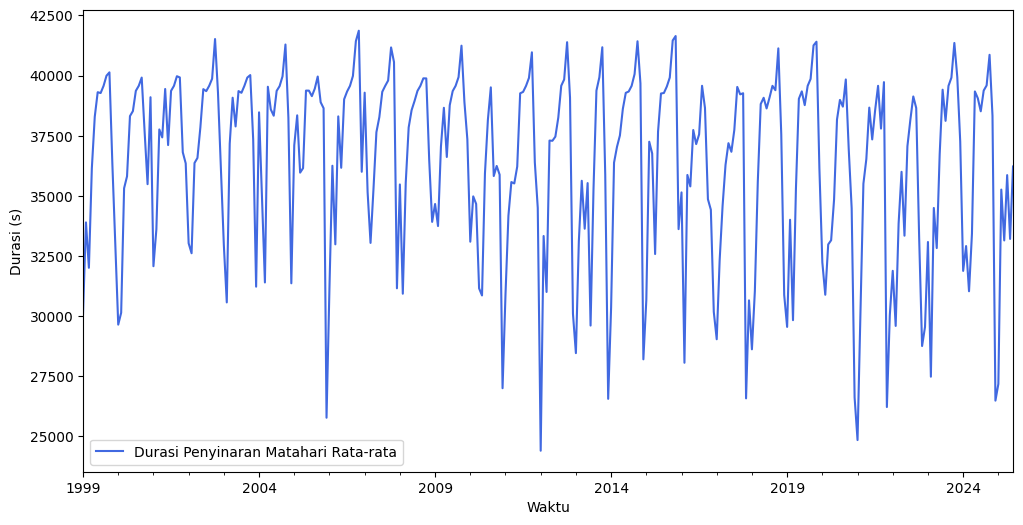

In [ ]:
# Plot Data Durasi Penyinaran Matahari Rata-rata
plot_DPM_mean = DPM_mean.plot(style = '-', figsize = (12, 6), color = 'royalblue', label = 'Durasi Penyinaran Matahari Rata-rata')
plot_DPM_mean.set_xlabel("Waktu")
plot_DPM_mean.set_ylabel("Durasi (s)")
plot_DPM_mean.legend()

In [ ]:
# Fitur Time Series
def create_features(data, target, lag_features, rolling_windows):
    # Salinan DataFrame (menghindari modifikasi data asli)
    data_features = data.copy()
    # Date-Time
    data_features['month'] = data_features.index.month
    data_features['year'] = data_features.index.year
    # Lag Features (berbasis bulanan)
    for lag in lag_features:
        data_features[f'{target}_lag_{lag}'] = data_features[target].shift(lag)
    # Rolling Windows
    for col in data.columns:
        for window in rolling_windows:
            data_features[f'{col}_mean_{window}'] = data_features[col].rolling(window = window).mean()
            data_features[f'{col}_std_{window}'] = data_features[col].rolling(window = window).std()
    # Cyclical Encoding untuk (pola bulanan)
    data_features['month_sin'] = np.sin(2 * np.pi * data_features['month']/12)
    data_features['month_cos'] = np.cos(2 * np.pi * data_features['month']/12)

    # Hapus baris dengan nilai NaN (yang dihasilkan dari shift dan rolling)
    data_features.dropna(inplace = True)

    return data_features

In [ ]:
# Split Data Asli Train & Test
def split_data(data, split_ratio):
    split_index = int(len(data) * split_ratio)
    train_data = data.iloc[:split_index].copy()
    test_data = data.iloc[split_index:].copy()
    return train_data, test_data

split_ratio = 0.8
train_mean_original, test_mean_original = split_data(data_mean, split_ratio)

In [ ]:
# Mendefinisikan Fitur
lag_features = [6, 12, 24]
rolling_windows = [6, 12, 24]

In [ ]:
# Split Data Hasil Feature Engineering Train & Test
train_mean_processed = create_features(train_mean_original, 'DPM Rata-rata', lag_features, rolling_windows)
test_mean_processed = create_features(test_mean_original, 'DPM Rata-rata', lag_features, rolling_windows)
X_train_mean = train_mean_processed.drop('DPM Rata-rata', axis = 1)
y_train_mean = train_mean_processed['DPM Rata-rata']
X_test_mean = test_mean_processed.drop('DPM Rata-rata', axis = 1)
y_test_mean = test_mean_processed['DPM Rata-rata']
print(f"Training - X: {X_train_mean.shape}, y: {y_train_mean.shape}")
print(f"Testing - X: {X_test_mean.shape}, y: {y_test_mean.shape}")

Training - X: (230, 13), y: (230,)
Testing - X: (40, 13), y: (40,)


In [ ]:
# Mengidentifikasi Parameter Terbaik
tss = TimeSeriesSplit(n_splits = 5)

reg = xgb.XGBRegressor(objective = 'reg:squarederror', eval_metric = 'rmse', use_label_encoder = False, n_jobs = -1)

parameters = {
    "max_depth": [3, 4],
    "learning_rate": [0.02, 0.03],
    "n_estimators": [100, 200],
    "subsample": [0.6, 0.7],
    "colsample_bytree": [0.6, 0.7],
    "min_child_weight": [12, 15],
    "gamma": [0, 0.1],
    "reg_alpha": [10, 15],
    "reg_lambda": [10, 15]
    }

In [ ]:
# Menjalankan Model
grid_search_mean = GridSearchCV(estimator = reg, param_grid = parameters, cv = tss, scoring = 'neg_mean_squared_error', verbose = 1, n_jobs = -1)
grid_search_mean.fit(X_train_mean, y_train_mean)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:03:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False,
                                    eval_metric='rmse', feature_types=None,
                                    feature_weights=None, gamma=No...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7], 'gamma': [0, 0.1],
                         'learning_rate': [0.02, 0.03], 'max_depth': [3, 4],
                         'min_child_weight': [12, 15],
                         'n_estimators': [100, 200], 'reg_alpha': [10, 15],
                         'reg_lambda': [10, 15], 'subsample': [0.6, 0.7]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
# Menampilkan Model Terbaik
print("Parameter Terbaik:")
best_params_mean = grid_search_mean.best_params_
print(best_params_mean)

print("\nSkor terbaik (Negated MSE):")
best_score_mean = grid_search_mean.best_score_
print(best_score_mean)

Parameter Terbaik:
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 12, 'n_estimators': 200, 'reg_alpha': 15, 'reg_lambda': 10, 'subsample': 0.7}

Skor terbaik (Negated MSE):
-5739884.334611427


In [ ]:
# Model Data Train dengan Parameter Terbaik
final_model_mean = xgb.XGBRegressor(**best_params_mean, n_jobs = -1, objective = 'reg:squarederror')
final_model_mean.fit(X_train_mean, y_train_mean)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=12, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Membuat Prediksi pada Data Training
y_train_pred_mean = final_model_mean.predict(X_train_mean)

In [ ]:
# Membuat Prediksi pada Data Testing
y_test_pred_mean = final_model_mean.predict(X_test_mean)

In [ ]:
# Feature Importance dari Model
importance_mean = final_model_mean.feature_importances_
feature_names_mean = X_train_mean.columns

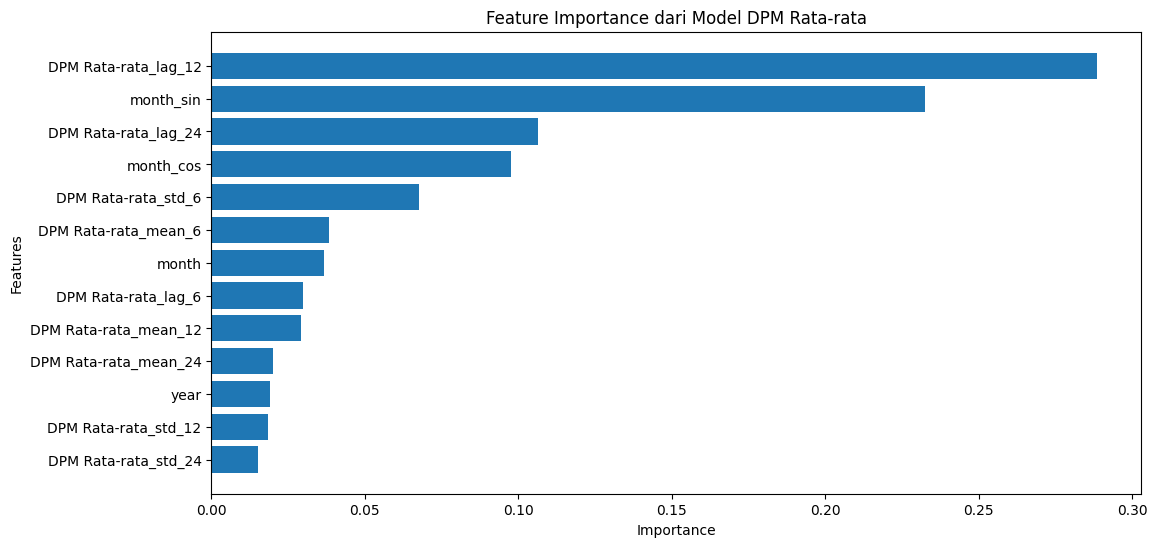

In [ ]:
# Visualisasi Feature Importance dari Model
feature_importance_data_mean = pd.DataFrame({
    'feature': feature_names_mean,
    'importance': importance_mean
})

feature_importance_data_mean = feature_importance_data_mean.sort_values(by = 'importance', ascending = False)

plt.figure(figsize = (12, 6))
plt.barh(feature_importance_data_mean['feature'], feature_importance_data_mean['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance dari Model DPM Rata-rata')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Fungsi MAPE
def mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    ape = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(ape) * 100

    return mape

In [ ]:
# Fungsi SMAPE
def symmetric_mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred))/2
    smape = np.mean(np.abs(y_true - y_pred)/denominator) * 100
    return smape

In [ ]:
# Evaluasi pada Data Training
mse_train_mean = mean_squared_error(y_train_mean, y_train_pred_mean)
rmse_train_mean = np.sqrt(mse_train_mean)
mape_train_mean = mean_absolute_percentage_error(y_train_mean, y_train_pred_mean)
smape_train_mean = symmetric_mean_absolute_percentage_error(y_train_mean, y_train_pred_mean)

print("Evaluasi pada Data Training:")
print(f"MSE: {mse_train_mean:.3f}")
print(f"RMSE: {rmse_train_mean:.3f}")
print(f"MAPE: {mape_train_mean:.3f}%")
print(f"SMAPE: {smape_train_mean:.3f}%")

Evaluasi pada Data Training:
MSE: 1967814.793
RMSE: 1402.788
MAPE: 2.825%
SMAPE: 2.781%


In [ ]:
# Evaluasi pada Data Testing
mse_test_mean = mean_squared_error(y_test_mean, y_test_pred_mean)
rmse_test_mean = np.sqrt(mse_test_mean)
mape_test_mean = mean_absolute_percentage_error(y_test_mean, y_test_pred_mean)
smape_test_mean = symmetric_mean_absolute_percentage_error(y_test_mean, y_test_pred_mean)

print("Evaluasi pada Data Testing:")
print(f"MSE: {mse_test_mean:.3f}")
print(f"RMSE: {rmse_test_mean:.3f}")
print(f"MAPE: {mape_test_mean:.3f}%")
print(f"SMAPE: {smape_test_mean:.3f}%")

Evaluasi pada Data Testing:
MSE: 4871001.947
RMSE: 2207.035
MAPE: 4.830%
SMAPE: 4.684%


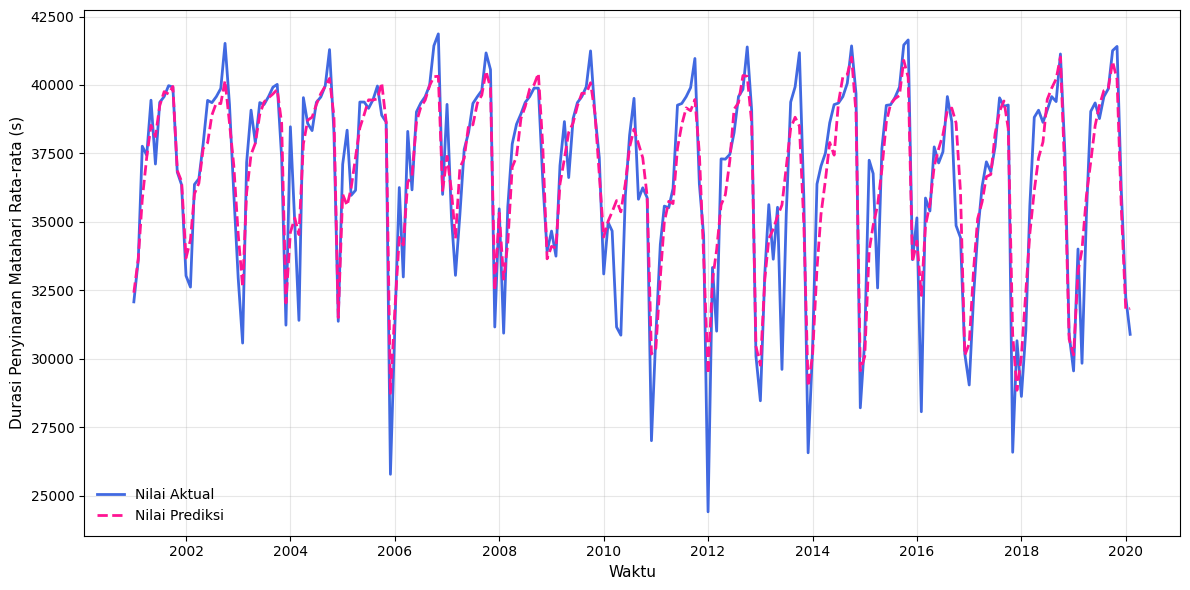

In [ ]:
# Visualisasi Data Train Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_train_mean,
    'prediksi': y_train_pred_mean
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Rata-rata (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

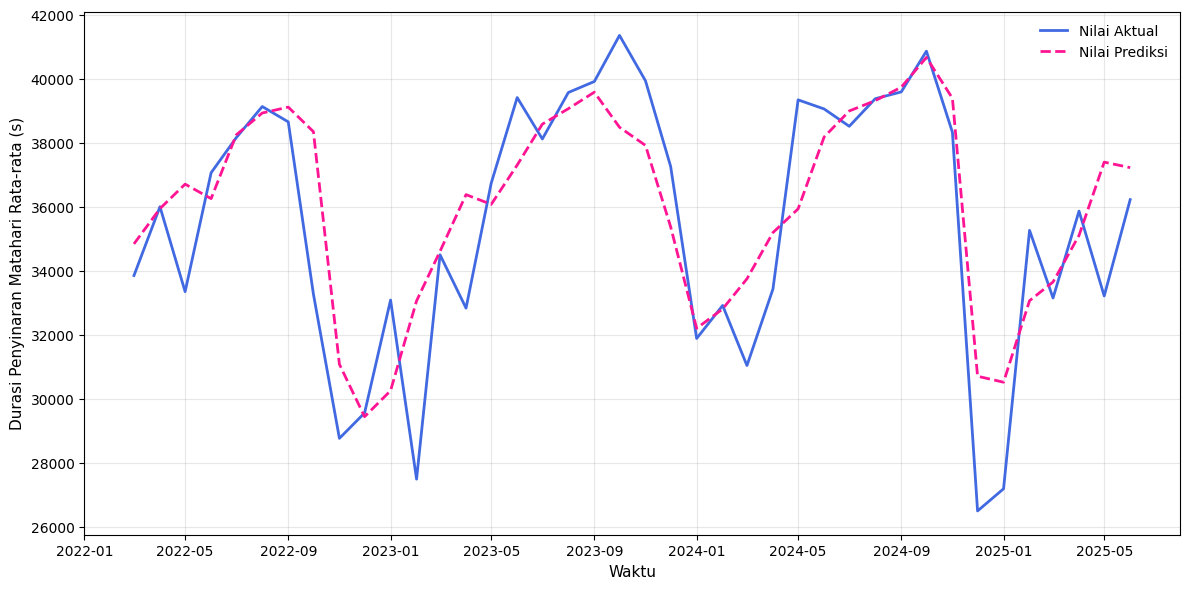

In [ ]:
# Visualisasi Data Test Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_test_mean,
    'prediksi': y_test_pred_mean
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Rata-rata (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

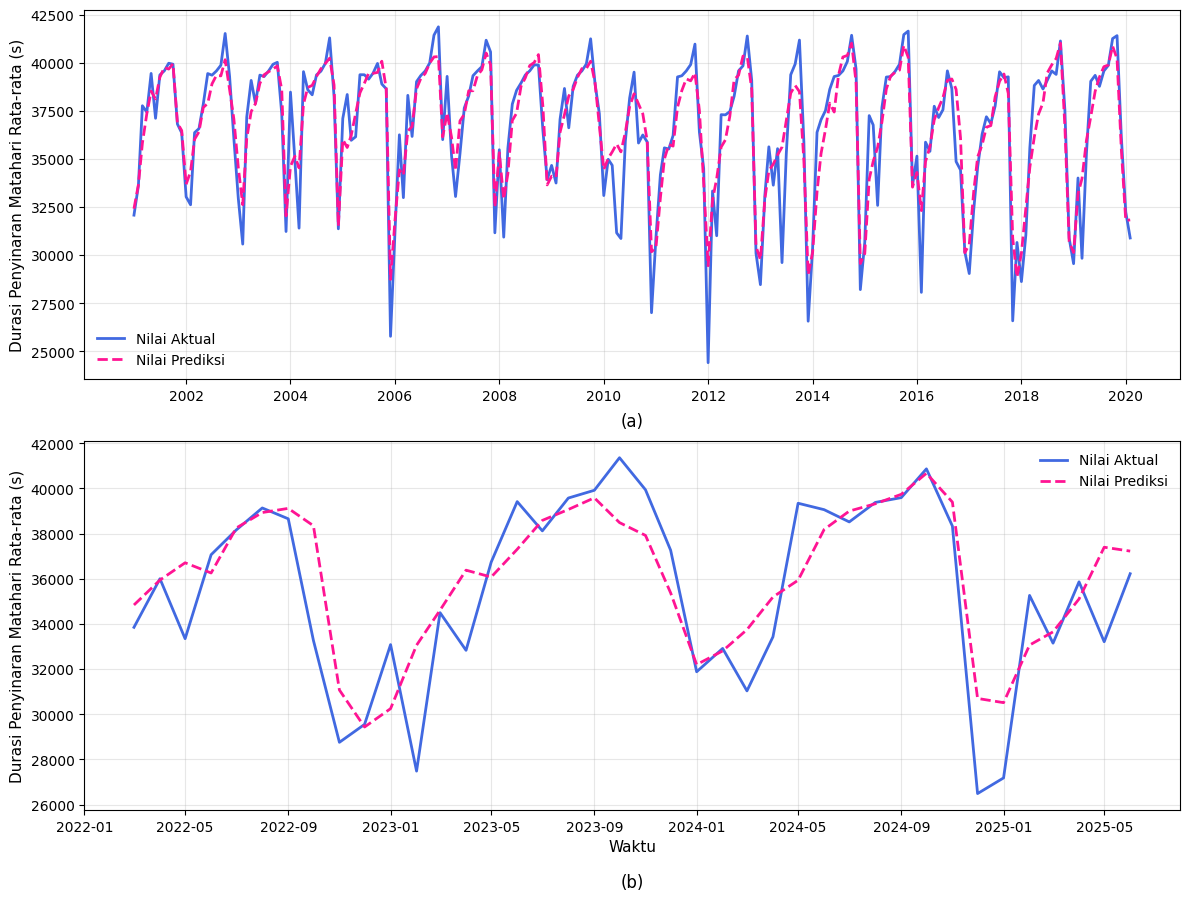

In [ ]:
# Visualisasi Data Train & Test Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_train_mean,
    'prediksi': y_train_pred_mean
})

hasil_test = pd.DataFrame({
    'aktual': y_test_mean,
    'prediksi': y_test_pred_mean
})

fig, axes = plt.subplots(2, 1, figsize = (12, 9))

axes[0].plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

axes[0].plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)
axes[0].set_ylabel('Durasi Penyinaran Matahari Rata-rata (s)', fontsize = 11)

axes[0].legend(frameon = False)
axes[0].grid(alpha = 0.3)
axes[0].set_title("(a)", y = -0.15)

axes[1].plot(
    hasil_test.index,
    hasil_test['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

axes[1].plot(
    hasil_test.index,
    hasil_test['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

axes[1].set_xlabel('Waktu', fontsize = 11)
axes[1].set_ylabel('Durasi Penyinaran Matahari Rata-rata (s)', fontsize = 11)
axes[1].legend(frameon = False)
axes[1].grid(alpha = 0.3)
axes[1].set_title("(b)", y = -0.23)

plt.tight_layout()
plt.show()

In [ ]:
# Data Train Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_train_mean, prediksi_train_mean in zip(y_train_mean, y_train_pred_mean):
    selisih_train_mean = aktual_train_mean - prediksi_train_mean
    print(f"  {aktual_train_mean:.3f}         {prediksi_train_mean:.3f}            {selisih_train_mean:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  32076.907         32412.768            -335.861
  33610.048         33655.473            -45.426
  37763.247         35824.133            1939.113
  37431.329         37354.477            76.852
  39444.251         38525.824            918.426
  37112.793         38117.977            -1005.184
  39365.385         39242.316            123.070
  39575.669         39756.934            -181.266
  39975.193         39671.047            304.145
  39923.471         39946.754            -23.285
  36814.700         36870.441            -55.742
  36352.766         36475.891            -123.125
  33030.051         33678.512            -648.461
  32616.551         34343.898            -1727.348
  36367.262         36023.414            343.848
  36577.674         36413.863            163.812
  37850.685         37675.344            175.340
  39437.745         37885.637            1552.109
  39355.194         38900.6

In [ ]:
# Data Test Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_test_mean, prediksi_test_mean in zip(y_test_mean, y_test_pred_mean):
    selisih_test_mean = aktual_test_mean - prediksi_test_mean
    print(f"  {aktual_test_mean:.3f}         {prediksi_test_mean:.3f}            {selisih_test_mean:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  33850.017         34839.555            -989.539
  36001.107         35942.816            58.289
  33345.512         36707.344            -3361.832
  37063.567         36255.188            808.379
  38160.630         38247.133            -86.504
  39134.017         38932.145            201.871
  38654.127         39115.680            -461.551
  33269.276         38347.758            -5078.480
  28758.852         31074.021            -2315.170
  29552.999         29436.531            116.469
  33083.854         30249.113            2834.742
  27483.654         33057.148            -5573.494
  34498.390         34608.754            -110.363
  32831.205         36379.785            -3548.582
  36736.414         36075.383            661.031
  39414.795         37304.016            2110.777
  38119.904         38583.836            -463.934
  39573.289         39066.758            506.531
  39916.975         3

In [ ]:
# Fungsi untuk Peramalan
def quick_forecast_future(model, X_train_features, all_processed_data, target_name, n_months):

    predictions = []
    historical_features = X_train_features.columns.tolist()

    current_data = all_processed_data.copy()

    all_values = current_data[target_name].tolist()

    print(f"Data historis tersedia: {len(all_values)} bulan")
    print(f"Data terakhir: {all_values[-1]:.3f}")

    last_date = current_data.index[-1]
    forecast_dates = pd.date_range(
        start = last_date + pd.DateOffset(months = 1),
        periods = n_months,
        freq = 'MS'
    )

    print(f"Forecast periode: {forecast_dates[0].strftime('%B %Y')} - {forecast_dates[-1].strftime('%B %Y')}")

    for i in range(n_months):

        input_features = pd.DataFrame()

        forecast_date = forecast_dates[i]
        month = forecast_date.month
        year = forecast_date.year

        if 'year' in historical_features:
            input_features['year'] = [year]

        if 'month' in historical_features:
            input_features['month'] = [month]

        for lag in lag_features:
            col_name = f'{target_name}_lag_{lag}'
            if col_name in historical_features:
                if len(all_values) >= lag:
                    input_features[col_name] = [all_values[-lag]]
                else:
                    input_features[col_name] = [np.nan]

        for window in rolling_windows:
            col_name = f'{target_name}_mean_{window}'
            if col_name in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name] = [temp_df[target_name].iloc[-window:].mean()]
                else:
                    input_features[col_name] = [np.nan]

            col_name_std = f'{target_name}_std_{window}'
            if col_name_std in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name_std] = [temp_df[target_name].iloc[-window:].std()]
                else:
                    input_features[col_name_std] = [np.nan]

        input_features['month_sin'] = [np.sin(2 * np.pi * month / 12)]
        input_features['month_cos'] = [np.cos(2 * np.pi * month / 12)]

        for col in historical_features:
            if col not in input_features.columns:

                input_features[col] = [X_train_features[col].mean()]

        input_features = input_features[historical_features]

        pred = model.predict(input_features)[0]
        predictions.append(pred)

        all_values.append(pred)

    return predictions, forecast_dates

In [ ]:
# Fungsi untuk Membuat Semua Data Diproses Fitur (Train + Test)
def prepare_all_data_for_forecast(train_original, test_original, target, lag_features, rolling_windows):

    all_data = pd.concat([train_original, test_original])

    all_processed = create_features(all_data, target, lag_features, rolling_windows)

    return all_processed

In [ ]:
# Menjalankan Fungsi Feature Engineering
all_mean_processed = prepare_all_data_for_forecast(
    train_mean_original,
    test_mean_original,
    'DPM Rata-rata',
    lag_features,
    rolling_windows
)
all_mean_processed.shape

(294, 14)

In [ ]:
# Melakukan Forecasting
pred_mean_future, dates_mean = quick_forecast_future(
        final_model_mean,
        X_train_mean,
        all_mean_processed,
        'DPM Rata-rata',
        n_months = 6
    )
for date, pred in zip(dates_mean, pred_mean_future):
        print(f"  {date.strftime('%B %Y')}: {pred:.3f}")

Data historis tersedia: 294 bulan
Data terakhir: 36222.824
Forecast periode: July 2025 - December 2025
  July 2025: 37748.207
  August 2025: 38729.066
  September 2025: 38968.477
  October 2025: 38773.242
  November 2025: 36688.762
  December 2025: 34794.719


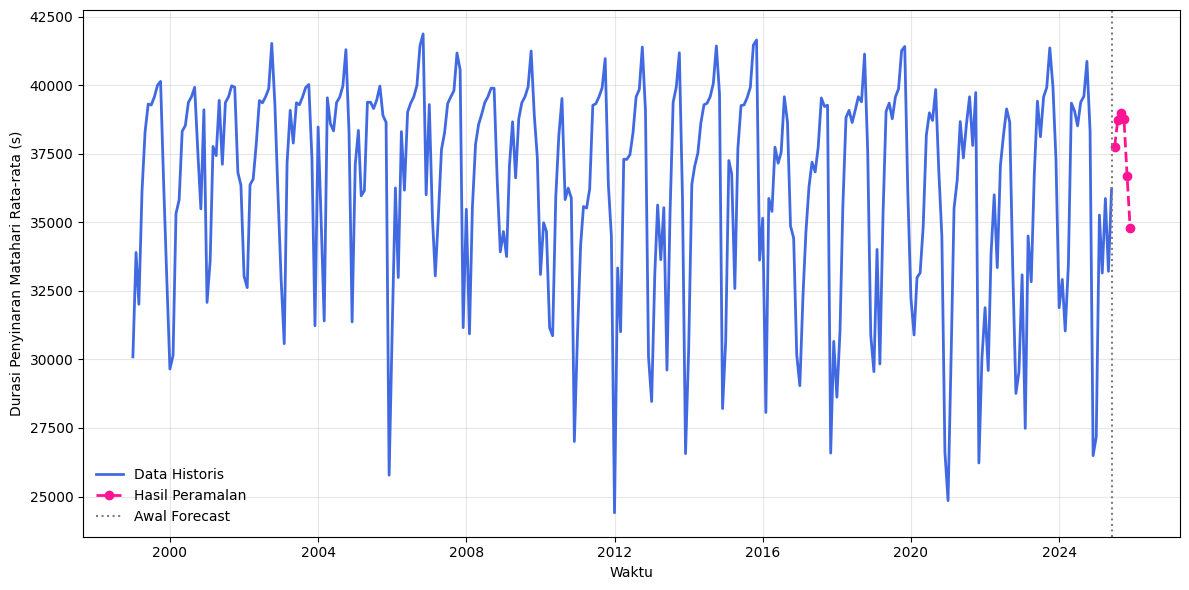

In [ ]:
# Visualisasi Hasil Peramalan
forecast_mean = pd.DataFrame({
    'tanggal': dates_mean,
    'prediksi': pred_mean_future
})
forecast_mean.set_index('tanggal', inplace = True)

historical_data_mean = data_mean[['DPM Rata-rata']].copy()
combined_mean = pd.concat([historical_data_mean, forecast_mean.rename(columns = {'prediksi': 'DPM Rata-rata'})])

plt.figure(figsize = (12, 6))

plt.plot(
    historical_data_mean.index,
    historical_data_mean['DPM Rata-rata'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_mean.index,
    forecast_mean['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_data_mean.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Rata-rata (s)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

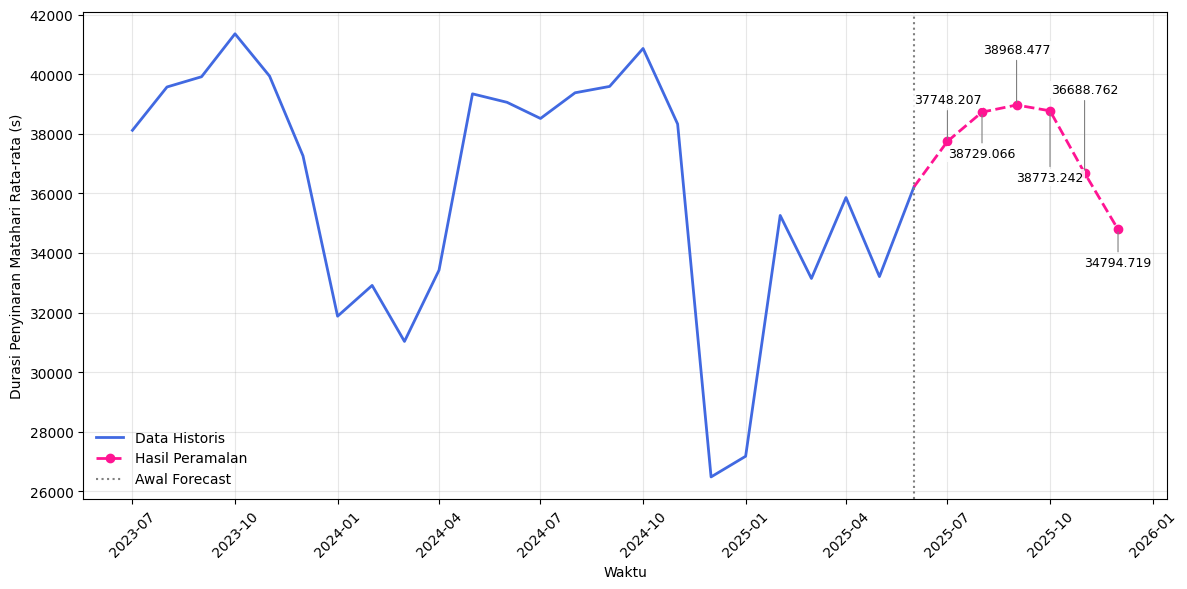

In [ ]:
# Visualisasi Hasil Peramalan
historical_tail_mean = data_mean[['DPM Rata-rata']].tail(24).copy()

forecast_mean = pd.DataFrame({
    'tanggal': dates_mean,
    'prediksi': pred_mean_future
})
forecast_mean.set_index('tanggal', inplace = True)

plt.figure(figsize = (12, 6))

plt.plot(
    historical_tail_mean.index,
    historical_tail_mean['DPM Rata-rata'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_mean.index,
    forecast_mean['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.plot(
    [historical_tail_mean.index[-1], forecast_mean.index[0]],
    [historical_tail_mean['DPM Rata-rata'].iloc[-1], forecast_mean['prediksi'].iloc[0]],
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.axvline(
    x = historical_tail_mean.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

offsets = [
    (0, 30),
    (0, -30),
    (0, 40),
    (0, -48),
    (0, 60),
    (0, -24)
]

for (x, y), (dx, dy) in zip(zip(forecast_mean.index, forecast_mean['prediksi']), offsets):
    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = (dx, dy),
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.85, edgecolor = 'none', pad = 1.2),
        arrowprops = dict(
            arrowstyle = '-',
            color = 'gray',
            lw = 0.8
        )
    )

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Rata-rata (s)')
plt.xticks(rotation = 45)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# DPM Maksimum

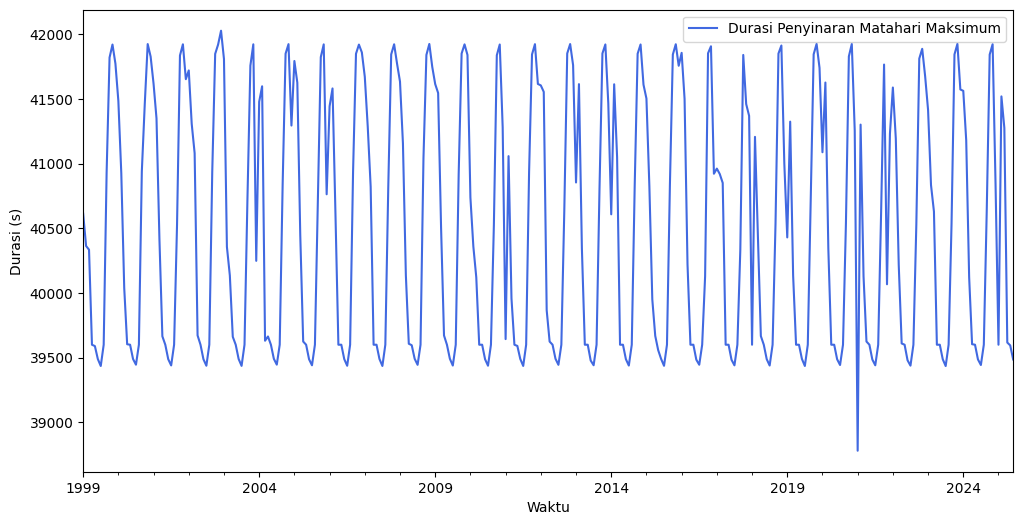

In [ ]:
# Plot Data Durasi Penyinaran Matahari Maksimum
plot_DPM_max = DPM_max.plot(style = '-', figsize = (12, 6), color = 'royalblue', label = 'Durasi Penyinaran Matahari Maksimum')
plot_DPM_max.set_xlabel("Waktu")
plot_DPM_max.set_ylabel("Durasi (s)")
plot_DPM_max.legend()

In [ ]:
# Fitur Time Series
def create_features(data, target, lag_features, rolling_windows):
    # Salinan DataFrame (menghindari modifikasi data asli)
    data_features = data.copy()
    # Date-Time
    data_features['month'] = data_features.index.month
    data_features['year'] = data_features.index.year
    # Lag Features (berbasis bulanan)
    for lag in lag_features:
        data_features[f'{target}_lag_{lag}'] = data_features[target].shift(lag)
    # Rolling Windows
    for col in data.columns:
        for window in rolling_windows:
            data_features[f'{col}_mean_{window}'] = data_features[col].rolling(window = window).mean()
            data_features[f'{col}_std_{window}'] = data_features[col].rolling(window = window).std()
    # Cyclical Encoding untuk (pola bulanan)
    data_features['month_sin'] = np.sin(2 * np.pi * data_features['month']/12)
    data_features['month_cos'] = np.cos(2 * np.pi * data_features['month']/12)

    # Hapus baris dengan nilai NaN (yang dihasilkan dari shift dan rolling)
    data_features.dropna(inplace = True)

    return data_features

In [ ]:
# Split Data Asli Train & Test
def split_data(data, split_ratio):
    split_index = int(len(data) * split_ratio)
    train_data = data.iloc[:split_index].copy()
    test_data = data.iloc[split_index:].copy()
    return train_data, test_data

split_ratio = 0.8
train_max_original, test_max_original = split_data(data_max, split_ratio)

In [ ]:
# Mendefinisikan Fitur
lag_features = [6, 12, 24]
rolling_windows = [6, 12, 24]

In [ ]:
# Split Data Hasil Feature Engineering Train & Test
train_max_processed = create_features(train_max_original, 'DPM Maksimum', lag_features, rolling_windows)
test_max_processed = create_features(test_max_original, 'DPM Maksimum', lag_features, rolling_windows)
X_train_max = train_max_processed.drop('DPM Maksimum', axis = 1)
y_train_max = train_max_processed['DPM Maksimum']
X_test_max = test_max_processed.drop('DPM Maksimum', axis = 1)
y_test_max = test_max_processed['DPM Maksimum']
print(f"Training - X: {X_train_max.shape}, y: {y_train_max.shape}")
print(f"Testing - X: {X_test_max.shape}, y: {y_test_max.shape}")

Training - X: (230, 13), y: (230,)
Testing - X: (40, 13), y: (40,)


In [ ]:
# Mengidentifikasi Parameter Terbaik
tss = TimeSeriesSplit(n_splits = 5)

reg = xgb.XGBRegressor(objective = 'reg:squarederror', eval_metric = 'rmse', use_label_encoder = False, n_jobs = -1)

parameters = {
    "max_depth": [3, 4],
    "learning_rate": [0.01, 0.02],
    "n_estimators": [100, 200],
    "subsample": [0.6, 0.7],
    "colsample_bytree": [0.6, 0.7],
    "min_child_weight": [10, 12],
    "gamma": [0, 0.1],
    "reg_alpha": [1, 5],
    "reg_lambda": [7, 10]
    }

In [ ]:
# Menjalankan Model
grid_search_max = GridSearchCV(estimator = reg, param_grid = parameters, cv = tss, scoring = 'neg_mean_squared_error', verbose = 1, n_jobs = -1)
grid_search_max.fit(X_train_max, y_train_max)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:05:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False,
                                    eval_metric='rmse', feature_types=None,
                                    feature_weights=None, gamma=No...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7], 'gamma': [0, 0.1],
                         'learning_rate': [0.01, 0.02], 'max_depth': [3, 4],
                         'min_child_weight': [10, 12],
                         'n_estimators': [100, 200], 'reg_alpha': [1, 5],
                         'reg_lambda': [7, 10], 'subsample': [0.6, 0.7]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
# Menampilkan Model Terbaik
print("Parameter Terbaik:")
best_params_max = grid_search_max.best_params_
print(best_params_max)

print("\nSkor terbaik (Negated MSE):")
best_score_max = grid_search_max.best_score_
print(best_score_max)

Parameter Terbaik:
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.02, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 200, 'reg_alpha': 5, 'reg_lambda': 7, 'subsample': 0.7}

Skor terbaik (Negated MSE):
-93460.43275490074


In [ ]:
# Model Data Train dengan Parameter Terbaik
final_model_max = xgb.XGBRegressor(**best_params_max, n_jobs = -1, objective = 'reg:squarederror')
final_model_max.fit(X_train_max, y_train_max)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Membuat Prediksi pada Data Training
y_train_pred_max = final_model_max.predict(X_train_max)

In [ ]:
# Membuat Prediksi pada Data Testing
y_test_pred_max = final_model_max.predict(X_test_max)

In [ ]:
# Feature Importance dari Model
importance_max = final_model_max.feature_importances_
feature_names_max = X_train_max.columns

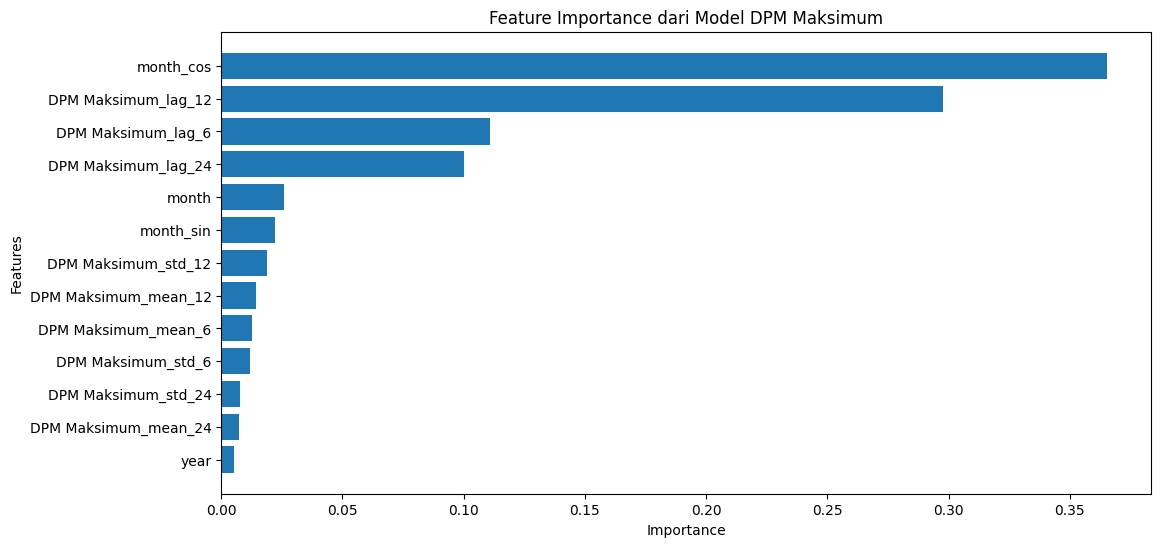

In [ ]:
# Visualisasi Feature Importance dari Model
feature_importance_data_max = pd.DataFrame({
    'feature': feature_names_max,
    'importance': importance_max
})

feature_importance_data_max = feature_importance_data_max.sort_values(by = 'importance', ascending = False)

plt.figure(figsize = (12, 6))
plt.barh(feature_importance_data_max['feature'], feature_importance_data_max['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance dari Model DPM Maksimum')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Fungsi MAPE
def mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    ape = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(ape) * 100

    return mape

In [ ]:
# Fungsi SMAPE
def symmetric_mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred))/2
    smape = np.mean(np.abs(y_true - y_pred)/denominator) * 100
    return smape

In [ ]:
# Evaluasi pada Data Training
mse_train_max = mean_squared_error(y_train_max, y_train_pred_max)
rmse_train_max = np.sqrt(mse_train_max)
mape_train_max = mean_absolute_percentage_error(y_train_max, y_train_pred_max)
smape_train_max = symmetric_mean_absolute_percentage_error(y_train_max, y_train_pred_max)

print("Evaluasi pada Data Training:")
print(f"MSE: {mse_train_max:.3f}")
print(f"RMSE: {rmse_train_max:.3f}")
print(f"MAPE: {mape_train_max:.3f}%")
print(f"SMAPE: {smape_train_max:.3f}%")

Evaluasi pada Data Training:
MSE: 40725.147
RMSE: 201.805
MAPE: 0.296%
SMAPE: 0.296%


In [ ]:
# Evaluasi pada Data Testing
mse_test_max = mean_squared_error(y_test_max, y_test_pred_max)
rmse_test_max = np.sqrt(mse_test_max)
mape_test_max = mean_absolute_percentage_error(y_test_max, y_test_pred_max)
smape_test_max = symmetric_mean_absolute_percentage_error(y_test_max, y_test_pred_max)

print("Evaluasi pada Data Testing:")
print(f"MSE: {mse_test_max:.3f}")
print(f"RMSE: {rmse_test_max:.3f}")
print(f"MAPE: {mape_test_max:.3f}%")
print(f"SMAPE: {smape_test_max:.3f}%")

Evaluasi pada Data Testing:
MSE: 125343.512
RMSE: 354.039
MAPE: 0.493%
SMAPE: 0.493%


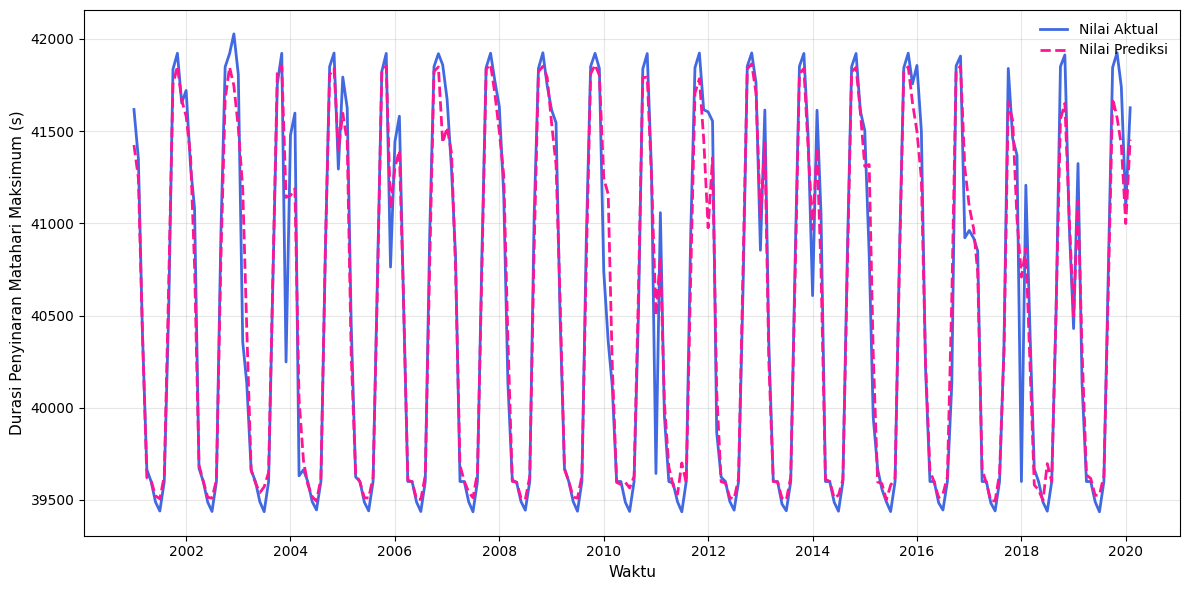

In [ ]:
# Visualisasi Data Train Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_train_max,
    'prediksi': y_train_pred_max
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Maksimum (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

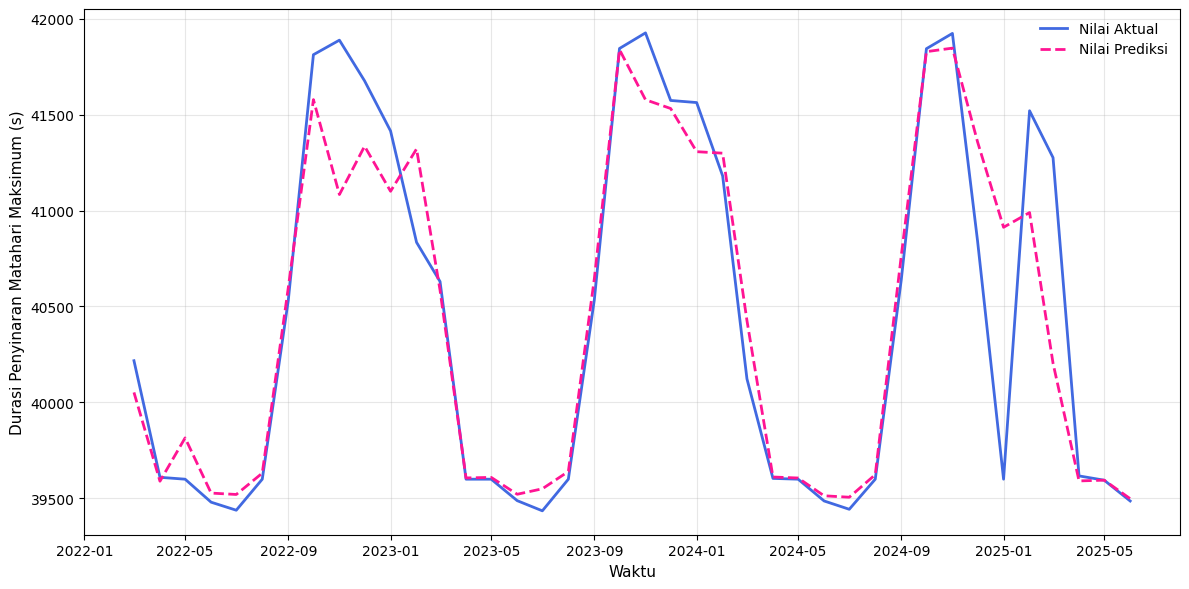

In [ ]:
# Visualisasi Data Test Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_test_max,
    'prediksi': y_test_pred_max
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Maksimum (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

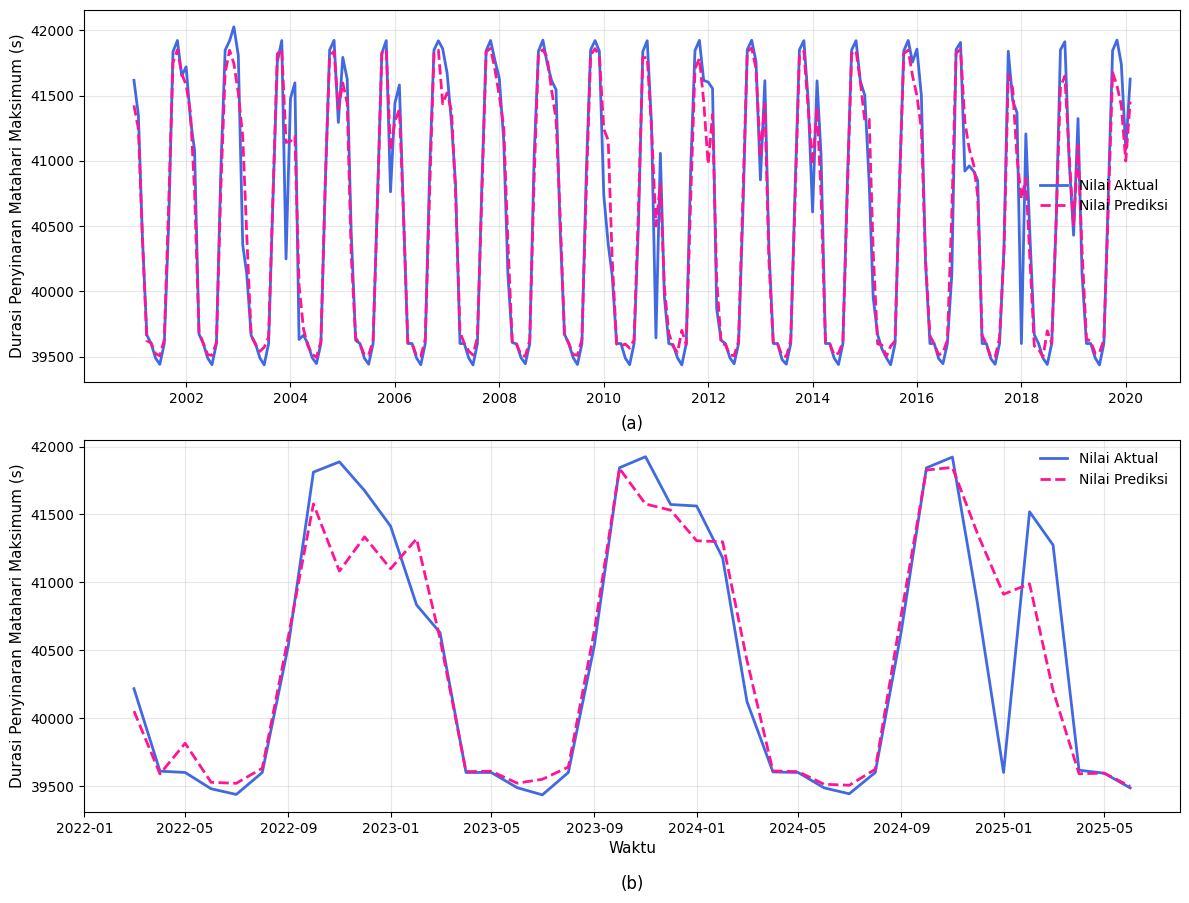

In [ ]:
# Visualisasi Data Train & Test Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_train_max,
    'prediksi': y_train_pred_max
})

hasil_test = pd.DataFrame({
    'aktual': y_test_max,
    'prediksi': y_test_pred_max
})

fig, axes = plt.subplots(2, 1, figsize = (12, 9))

axes[0].plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

axes[0].plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

axes[0].set_ylabel('Durasi Penyinaran Matahari Maksimum (s)', fontsize = 11)
axes[0].legend(frameon = False)
axes[0].set_title("(a)", y = -0.15)
axes[0].grid(alpha = 0.3)

axes[1].plot(
    hasil_test.index,
    hasil_test['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

axes[1].plot(
    hasil_test.index,
    hasil_test['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

axes[1].set_xlabel('Waktu', fontsize = 11)
axes[1].set_ylabel('Durasi Penyinaran Matahari Maksimum (s)', fontsize = 11)
axes[1].set_title("(b)", y = -0.23)
axes[1].legend(frameon = False)
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Data Train Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_train_max, prediksi_train_max in zip(y_train_max, y_train_pred_max):
    selisih_train_max = aktual_train_max - prediksi_train_max
    print(f"  {aktual_train_max:.3f}         {prediksi_train_max:.3f}            {selisih_train_max:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  41617.500         41424.906            192.594
  41350.230         41245.070            105.160
  40416.040         40414.133            1.906
  39665.160         39621.379            43.781
  39600.000         39604.270            -4.270
  39488.300         39522.348            -34.047
  39440.020         39506.043            -66.023
  39600.000         39629.539            -29.539
  40527.120         40672.977            -145.855
  41835.970         41752.980            82.988
  41922.620         41852.031            70.590
  41652.810         41668.379            -15.570
  41720.650         41580.887            139.762
  41308.200         41364.406            -56.207
  41080.890         40767.309            313.582
  39672.180         39689.262            -17.082
  39600.000         39601.215            -1.215
  39488.040         39514.949            -26.910
  39437.700         39509.535            -

In [ ]:
# Data Test Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_test_max, prediksi_test_max in zip(y_test_max, y_test_pred_max):
    selisih_test_max = aktual_test_max - prediksi_test_max
    print(f"  {aktual_test_max:.3f}         {prediksi_test_max:.3f}            {selisih_test_max:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  40217.320         40052.141            165.180
  39609.800         39589.434            20.367
  39600.000         39815.133            -215.133
  39480.160         39527.590            -47.430
  39438.310         39520.344            -82.035
  39600.000         39631.543            -31.543
  40531.090         40596.863            -65.773
  41811.900         41577.801            234.098
  41887.670         41083.148            804.523
  41675.660         41335.047            340.613
  41414.380         41100.203            314.176
  40834.110         41320.984            -486.875
  40629.890         40584.574            45.316
  39600.000         39606.500            -6.500
  39600.000         39609.340            -9.340
  39488.160         39521.426            -33.266
  39435.150         39550.031            -114.883
  39600.000         39640.125            -40.125
  40535.210         40644.812        

In [ ]:
# Fungsi untuk Peramalan
def quick_forecast_future(model, X_train_features, all_processed_data, target_name, n_months):

    predictions = []
    historical_features = X_train_features.columns.tolist()

    current_data = all_processed_data.copy()

    all_values = current_data[target_name].tolist()

    print(f"Data historis tersedia: {len(all_values)} bulan")
    print(f"Data terakhir: {all_values[-1]:.3f}")

    last_date = current_data.index[-1]
    forecast_dates = pd.date_range(
        start = last_date + pd.DateOffset(months = 1),
        periods = n_months,
        freq = 'MS'
    )

    print(f"Forecast periode: {forecast_dates[0].strftime('%B %Y')} - {forecast_dates[-1].strftime('%B %Y')}")

    for i in range(n_months):

        input_features = pd.DataFrame()

        forecast_date = forecast_dates[i]
        month = forecast_date.month
        year = forecast_date.year

        if 'year' in historical_features:
            input_features['year'] = [year]

        if 'month' in historical_features:
            input_features['month'] = [month]

        for lag in lag_features:
            col_name = f'{target_name}_lag_{lag}'
            if col_name in historical_features:
                if len(all_values) >= lag:
                    input_features[col_name] = [all_values[-lag]]
                else:
                    input_features[col_name] = [np.nan]

        for window in rolling_windows:
            col_name = f'{target_name}_mean_{window}'
            if col_name in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name] = [temp_df[target_name].iloc[-window:].mean()]
                else:
                    input_features[col_name] = [np.nan]

            col_name_std = f'{target_name}_std_{window}'
            if col_name_std in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name_std] = [temp_df[target_name].iloc[-window:].std()]
                else:
                    input_features[col_name_std] = [np.nan]

        input_features['month_sin'] = [np.sin(2 * np.pi * month / 12)]
        input_features['month_cos'] = [np.cos(2 * np.pi * month / 12)]

        for col in historical_features:
            if col not in input_features.columns:

                input_features[col] = [X_train_features[col].mean()]

        input_features = input_features[historical_features]

        pred = model.predict(input_features)[0]
        predictions.append(pred)

        all_values.append(pred)

    return predictions, forecast_dates

In [ ]:
# Fungsi untuk Membuat Semua Data Diproses Fitur (Train + Test)
def prepare_all_data_for_forecast(train_original, test_original, target, lag_features, rolling_windows):

    all_data = pd.concat([train_original, test_original])

    all_processed = create_features(all_data, target, lag_features, rolling_windows)

    return all_processed

In [ ]:
# Menjalankan Fungsi Feature Engineering
all_max_processed = prepare_all_data_for_forecast(
    train_max_original,
    test_max_original,
    'DPM Maksimum',
    lag_features,
    rolling_windows
)
all_max_processed.shape

(294, 14)

In [ ]:
# Melakukan Forecasting
pred_max_future, dates_max = quick_forecast_future(
        final_model_max,
        X_train_max,
        all_max_processed,
        'DPM Maksimum',
        n_months = 6
    )
for date, pred in zip(dates_max, pred_max_future):
        print(f"  {date.strftime('%B %Y')}: {pred:.3f}")

Data historis tersedia: 294 bulan
Data terakhir: 39486.350
Forecast periode: July 2025 - December 2025
  July 2025: 39813.461
  August 2025: 39576.914
  September 2025: 40444.133
  October 2025: 41580.199
  November 2025: 41588.891
  December 2025: 40850.340


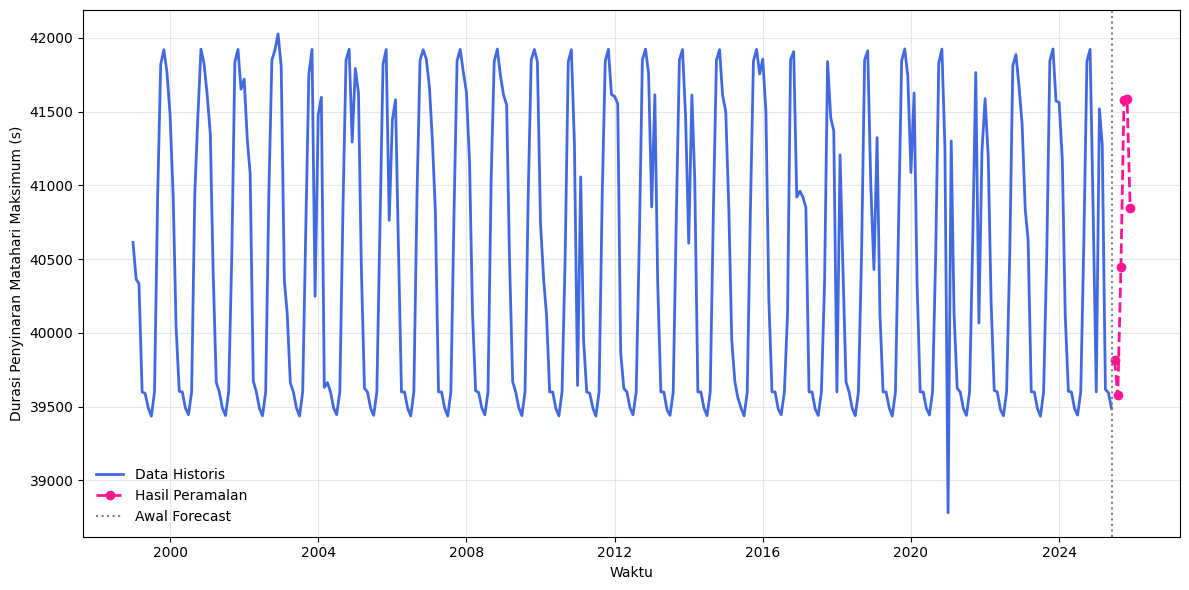

In [ ]:
# Visualisasi Hasil Peramalan
forecast_max = pd.DataFrame({
    'tanggal': dates_max,
    'prediksi': pred_max_future
})
forecast_max.set_index('tanggal', inplace = True)

historical_data_max = data_max[['DPM Maksimum']].copy()
combined_max = pd.concat([historical_data_max, forecast_max.rename(columns = {'prediksi': 'DPM Maksimum'})])

plt.figure(figsize = (12, 6))

plt.plot(
    historical_data_max.index,
    historical_data_max['DPM Maksimum'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_max.index,
    forecast_max['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_data_max.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Maksimum (s)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

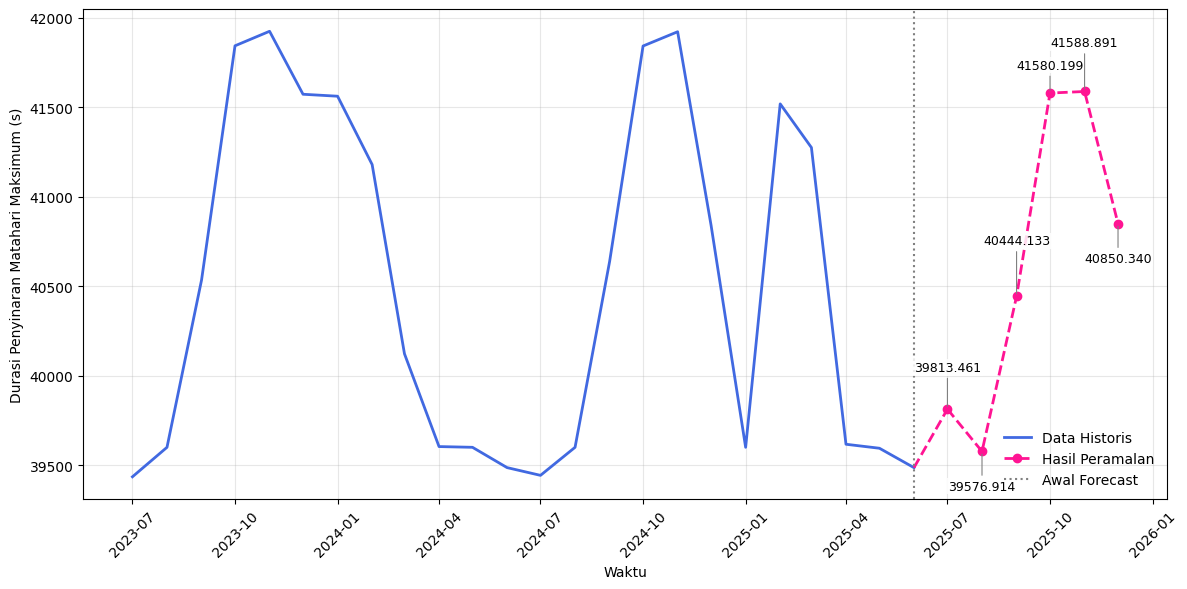

In [ ]:
# Visualisasi Hasil Peramalan
historical_tail_max = data_max[['DPM Maksimum']].tail(24).copy()

forecast_max = pd.DataFrame({
    'tanggal': dates_max,
    'prediksi': pred_max_future
})
forecast_max.set_index('tanggal', inplace = True)

plt.figure(figsize = (12, 6))

plt.plot(
    historical_tail_max.index,
    historical_tail_max['DPM Maksimum'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_max.index,
    forecast_max['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.plot(
    [historical_tail_max.index[-1], forecast_max.index[0]],
    [historical_tail_max['DPM Maksimum'].iloc[-1], forecast_max['prediksi'].iloc[0]],
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.axvline(
    x = historical_tail_max.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

offsets = [
    (0, 30),
    (0, -25),
    (0, 40),
    (0, 20),
    (0, 35),
    (0, -25)
]

for (x, y), (dx, dy) in zip(zip(forecast_max.index, forecast_max['prediksi']), offsets):
    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = (dx, dy),
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.85, edgecolor = 'none', pad = 1.2),
        arrowprops = dict(
            arrowstyle = '-',
            color = 'gray',
            lw = 0.8
        )
    )

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Maksimum (s)')
plt.xticks(rotation = 45)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# DPM Minimum

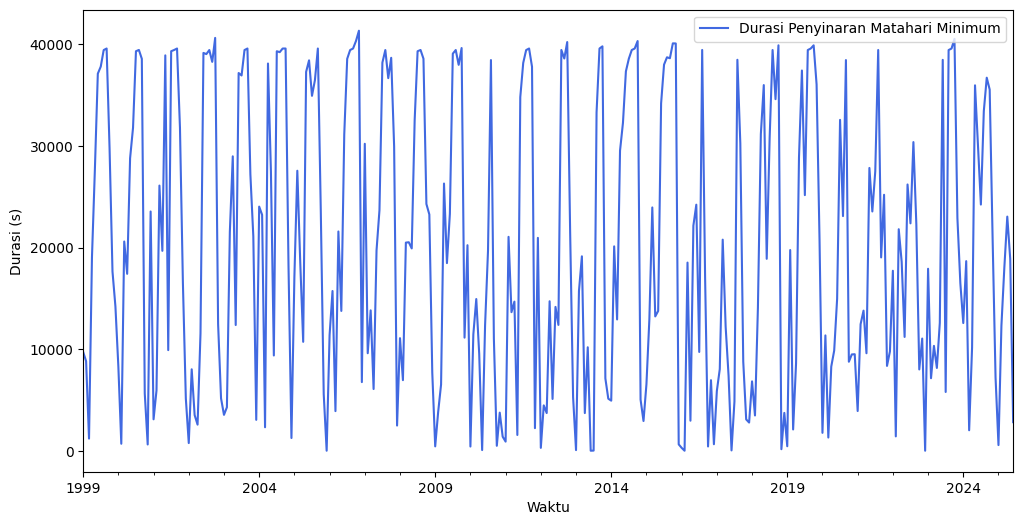

In [ ]:
# Plot Data Durasi Penyinaran Matahari Minimum
plot_DPM_min = DPM_min.plot(style = '-', figsize = (12, 6), color = 'royalblue', label = 'Durasi Penyinaran Matahari Minimum')
plot_DPM_min.set_xlabel("Waktu")
plot_DPM_min.set_ylabel("Durasi (s)")
plot_DPM_min.legend()

In [ ]:
# Fitur Time Series
def create_features(data, target, lag_features, rolling_windows):
    # Salinan DataFrame (menghindari modifikasi data asli)
    data_features = data.copy()
    # Date-Time
    data_features['month'] = data_features.index.month
    data_features['year'] = data_features.index.year
    # Lag Features (berbasis bulanan)
    for lag in lag_features:
        data_features[f'{target}_lag_{lag}'] = data_features[target].shift(lag)
    # Rolling Windows
    for col in data.columns:
        for window in rolling_windows:
            data_features[f'{col}_mean_{window}'] = data_features[col].rolling(window = window).mean()
            data_features[f'{col}_std_{window}'] = data_features[col].rolling(window = window).std()
    # Cyclical Encoding untuk (pola bulanan)
    data_features['month_sin'] = np.sin(2 * np.pi * data_features['month']/12)
    data_features['month_cos'] = np.cos(2 * np.pi * data_features['month']/12)

    # Hapus baris dengan nilai NaN (yang dihasilkan dari shift dan rolling)
    data_features.dropna(inplace = True)

    return data_features

In [ ]:
# Split Data Asli Train & Test
def split_data(data, split_ratio):
    split_index = int(len(data) * split_ratio)
    train_data = data.iloc[:split_index].copy()
    test_data = data.iloc[split_index:].copy()
    return train_data, test_data

split_ratio = 0.8
train_min_original, test_min_original = split_data(data_min, split_ratio)

In [ ]:
# Mendefinisikan Fitur
lag_features = [3, 6, 12]
rolling_windows = [3, 6, 12]

In [ ]:
# Split Data Hasil Feature Engineering Train & Test
train_min_processed = create_features(train_min_original, 'DPM Minimum', lag_features, rolling_windows)
test_min_processed = create_features(test_min_original, 'DPM Minimum', lag_features, rolling_windows)
X_train_min = train_min_processed.drop('DPM Minimum', axis = 1)
y_train_min = train_min_processed['DPM Minimum']
X_test_min = test_min_processed.drop('DPM Minimum', axis = 1)
y_test_min = test_min_processed['DPM Minimum']
print(f"Training - X: {X_train_min.shape}, y: {y_train_min.shape}")
print(f"Testing - X: {X_test_min.shape}, y: {y_test_min.shape}")

Training - X: (242, 13), y: (242,)
Testing - X: (52, 13), y: (52,)


In [ ]:
# Mengidentifikasi Parameter Terbaik
tss = TimeSeriesSplit(n_splits = 5)

reg = xgb.XGBRegressor(objective = 'reg:squarederror', eval_metric = 'rmse', use_label_encoder = False, n_jobs = -1)

parameters = {
    "max_depth": [4, 5],
    "learning_rate": [0.01, 0.02],
    "n_estimators": [200, 300],
    "subsample": [0.6, 0.7],
    "colsample_bytree": [0.6, 0.7],
    "min_child_weight": [10, 15],
    "gamma": [1, 5],
    "reg_alpha": [5, 10],
    "reg_lambda": [1, 5]
}

In [ ]:
# Menjalankan Model
grid_search_min = GridSearchCV(estimator = reg, param_grid = parameters, cv = tss, scoring = 'neg_mean_squared_error', verbose = 1, n_jobs = -1, return_train_score = True)
grid_search_min.fit(X_train_min, y_train_min)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:07:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False,
                                    eval_metric='rmse', feature_types=None,
                                    feature_weights=None, gamma=No...
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7], 'gamma': [1, 5],
                         'learning_rate': [0.01, 0.02], 'max_depth': [4, 5],
                         'min_child_weight': [10, 15],
                         'n_estimators': [200, 300], 'reg_alpha': [5, 10],
                         'reg_lambda': [1, 5], 'subsample': [0.6, 0.7]},
             return_train_score=True, scoring='neg_mean_squared_error',
             verbose=1)

In [ ]:
# Menampilkan Model Terbaik
print("Parameter Terbaik:")
best_params_min = grid_search_min.best_params_
print(best_params_min)

print("\nSkor terbaik (Negated MSE):")
best_score_min = grid_search_min.best_score_
print(best_score_min)

Parameter Terbaik:
{'colsample_bytree': 0.7, 'gamma': 1, 'learning_rate': 0.02, 'max_depth': 5, 'min_child_weight': 15, 'n_estimators': 300, 'reg_alpha': 5, 'reg_lambda': 1, 'subsample': 0.7}

Skor terbaik (Negated MSE):
-65004078.049956106


In [ ]:
# Model Data Train dengan Parameter Terbaik
final_model_min = xgb.XGBRegressor(**best_params_min, n_jobs = -1, objective = 'reg:squarederror')
final_model_min.fit(X_train_min, y_train_min)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=15, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Membuat Prediksi pada Data Training
y_train_pred_min = final_model_min.predict(X_train_min)

In [ ]:
# Membuat Prediksi pada Data Testing
y_test_pred_min = final_model_min.predict(X_test_min)

In [ ]:
# Feature Importance dari Model
importance_min = final_model_min.feature_importances_
feature_names_min = X_train_min.columns

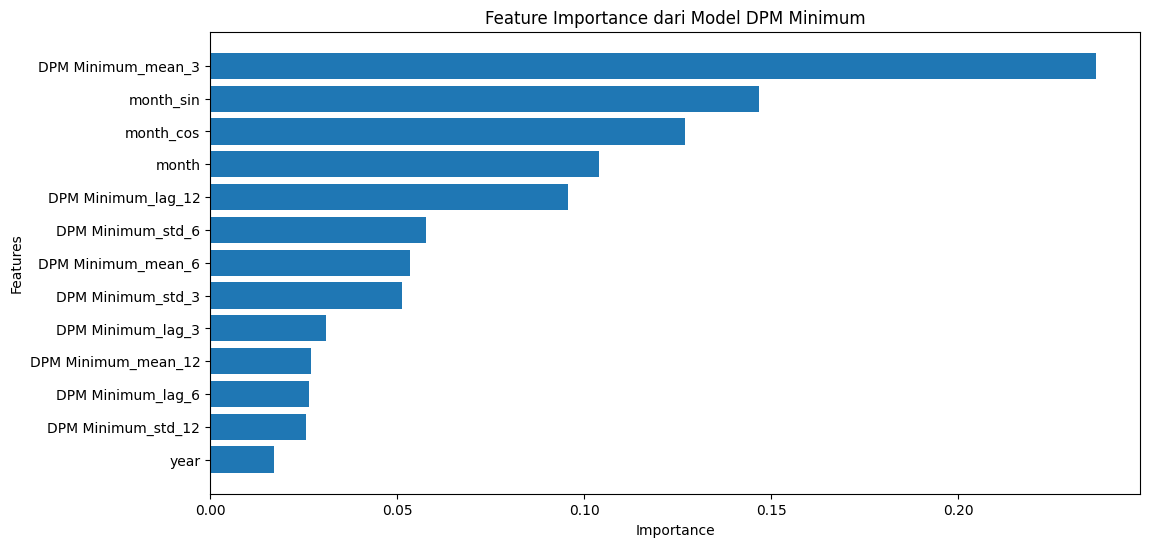

In [ ]:
# Visualisasi Feature Importance dari Model
feature_importance_data_min = pd.DataFrame({
    'feature': feature_names_min,
    'importance': importance_min
})

feature_importance_data_min = feature_importance_data_min.sort_values(by = 'importance', ascending = False)

plt.figure(figsize = (12, 6))
plt.barh(feature_importance_data_min['feature'], feature_importance_data_min['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance dari Model DPM Minimum')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Fungsi MAPE
def mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    ape = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(ape) * 100

    return mape

In [ ]:
# Fungsi SMAPE
def symmetric_mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred))/2
    smape = np.mean(np.abs(y_true - y_pred)/denominator) * 100
    return smape

In [ ]:
# Evaluasi pada Data Training
mse_train_min = mean_squared_error(y_train_min, y_train_pred_min)
rmse_train_min = np.sqrt(mse_train_min)
mape_train_min = mean_absolute_percentage_error(y_train_min, y_train_pred_min)
smape_train_min = symmetric_mean_absolute_percentage_error(y_train_min, y_train_pred_min)

print("Evaluasi pada Data Training:")
print(f"MSE: {mse_train_min:.3f}")
print(f"RMSE: {rmse_train_min:.3f}")
print(f"MAPE: {mape_train_min:.3f}%")
print(f"SMAPE: {smape_train_min:.3f}%")

Evaluasi pada Data Training:
MSE: 16208530.381
RMSE: 4025.982
MAPE: inf%
SMAPE: 33.756%


/tmp/ipykernel_16177/3585704908.py:6: RuntimeWarning: divide by zero encountered in divide
  ape = np.abs((y_true - y_pred) / y_true)


In [ ]:
# Evaluasi pada Data Testing
mse_test_min = mean_squared_error(y_test_min, y_test_pred_min)
rmse_test_min = np.sqrt(mse_test_min)
mape_test_min = mean_absolute_percentage_error(y_test_min, y_test_pred_min)
smape_test_min = symmetric_mean_absolute_percentage_error(y_test_min, y_test_pred_min)

print("Evaluasi pada Data Testing:")
print(f"MSE: {mse_test_min:.3f}")
print(f"RMSE: {rmse_test_min:.3f}")
print(f"MAPE: {mape_test_min:.3f}%")
print(f"SMAPE: {smape_test_min:.3f}%")

Evaluasi pada Data Testing:
MSE: 45496507.567
RMSE: 6745.110
MAPE: inf%
SMAPE: 37.972%


/tmp/ipykernel_16177/3585704908.py:6: RuntimeWarning: divide by zero encountered in divide
  ape = np.abs((y_true - y_pred) / y_true)


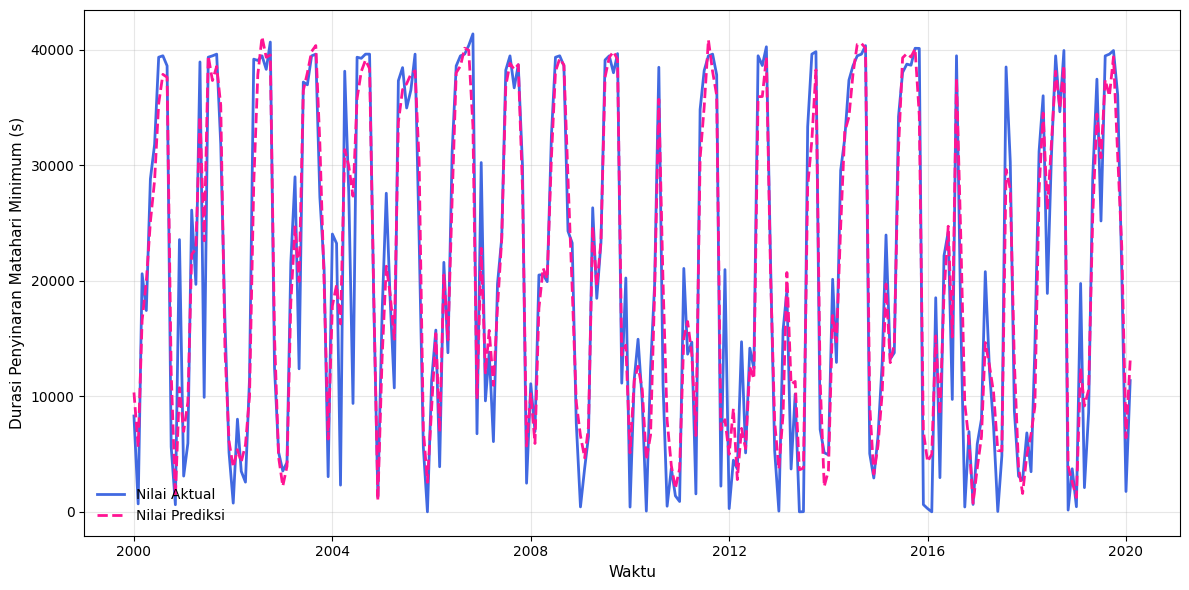

In [ ]:
# Visualisasi Data Train Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_train_min,
    'prediksi': y_train_pred_min
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Minimum (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

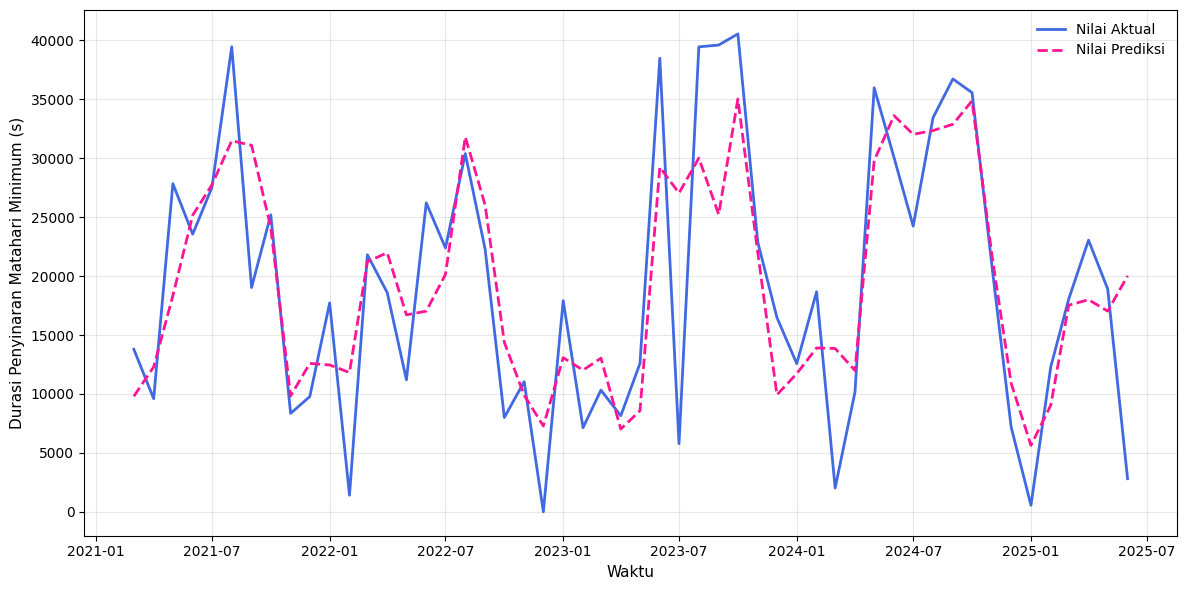

In [ ]:
# Visualisasi Data Test Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_test_min,
    'prediksi': y_test_pred_min
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Minimum (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

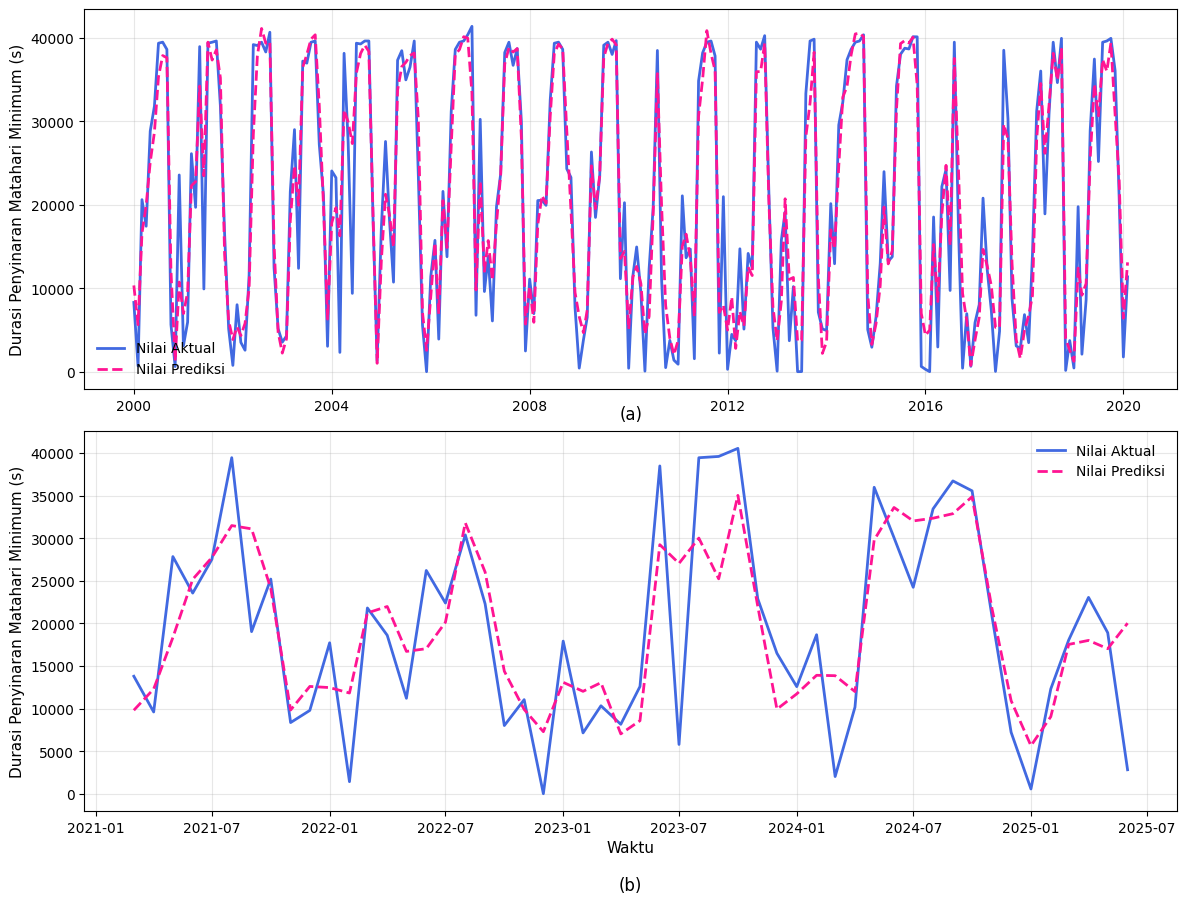

In [ ]:
# Visualisasi Data Train & Test Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_train_min,
    'prediksi': y_train_pred_min
})

hasil_test = pd.DataFrame({
    'aktual': y_test_min,
    'prediksi': y_test_pred_min
})

fig, axes = plt.subplots(2, 1, figsize = (12, 9))

axes[0].plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

axes[0].plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

axes[0].set_ylabel('Durasi Penyinaran Matahari Minimum (s)', fontsize = 11)
axes[0].set_title("(a)", y = -0.10)
axes[0].legend(frameon = False)
axes[0].grid(alpha = 0.3)

axes[1].plot(
    hasil_test.index,
    hasil_test['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

axes[1].plot(
    hasil_test.index,
    hasil_test['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

axes[1].set_xlabel('Waktu', fontsize = 11)
axes[1].set_ylabel('Durasi Penyinaran Matahari Minimum (s)', fontsize = 11)
axes[1].set_title("(b)", y = -0.23)
axes[1].legend(frameon = False)
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Data Train Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_train_min, prediksi_train_min in zip(y_train_min, y_train_pred_min):
    selisih_train_min = aktual_train_min - prediksi_train_min
    print(f"  {aktual_train_min:.3f}         {prediksi_train_min:.3f}            {selisih_train_min:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  8289.860         10326.737            -2036.877
  686.720         5627.926            -4941.206
  20599.380         16555.793            4043.588
  17417.370         19925.422            -2508.053
  28800.000         25089.486            3710.514
  31795.200         28687.998            3107.201
  39332.820         35327.059            4005.762
  39458.800         37851.516            1607.285
  38588.180         37599.625            988.555
  5636.370         12114.553            -6478.183
  615.430         1300.471            -685.041
  23553.690         10734.553            12819.137
  3092.910         6955.106            -3862.196
  5933.420         9501.419            -3567.999
  26104.590         22270.910            3833.680
  19680.310         22746.436            -3066.125
  38925.200         34209.480            4715.719
  9904.110         23447.273            -13543.163
  39334.970         39

In [ ]:
# Data Test Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_test_min, prediksi_test_min in zip(y_test_min, y_test_pred_min):
    selisih_test_min = aktual_test_min - prediksi_test_min
    print(f"  {aktual_test_min:.3f}         {prediksi_test_min:.3f}            {selisih_test_min:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  13791.190         9799.757            3991.434
  9597.540         12294.793            -2697.253
  27839.950         18338.381            9501.568
  23555.740         25172.074            -1616.334
  27519.590         27736.438            -216.848
  39454.640         31483.000            7971.641
  19030.470         31096.330            -12065.859
  25200.000         24114.621            1085.379
  8352.080         9824.134            -1472.054
  9778.520         12594.590            -2816.070
  17718.880         12460.032            5258.849
  1411.370         11820.309            -10408.938
  21808.400         21226.172            582.229
  18599.730         21979.072            -3379.342
  11203.400         16708.168            -5504.768
  26212.640         17027.902            9184.738
  22386.630         20140.936            2245.695
  30387.340         31804.482            -1417.143
  22284.200   

In [ ]:
# Fungsi untuk Peramalan
def quick_forecast_future(model, X_train_features, all_processed_data, target_name, n_months):

    predictions = []
    historical_features = X_train_features.columns.tolist()

    current_data = all_processed_data.copy()

    all_values = current_data[target_name].tolist()

    print(f"Data historis tersedia: {len(all_values)} bulan")
    print(f"Data terakhir: {all_values[-1]:.3f}")

    last_date = current_data.index[-1]
    forecast_dates = pd.date_range(
        start = last_date + pd.DateOffset(months = 1),
        periods = n_months,
        freq = 'MS'
    )

    print(f"Forecast periode: {forecast_dates[0].strftime('%B %Y')} - {forecast_dates[-1].strftime('%B %Y')}")

    for i in range(n_months):

        input_features = pd.DataFrame()

        forecast_date = forecast_dates[i]
        month = forecast_date.month
        year = forecast_date.year

        if 'year' in historical_features:
            input_features['year'] = [year]

        if 'month' in historical_features:
            input_features['month'] = [month]

        for lag in lag_features:
            col_name = f'{target_name}_lag_{lag}'
            if col_name in historical_features:
                if len(all_values) >= lag:
                    input_features[col_name] = [all_values[-lag]]
                else:
                    input_features[col_name] = [np.nan]

        for window in rolling_windows:
            col_name = f'{target_name}_mean_{window}'
            if col_name in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name] = [temp_df[target_name].iloc[-window:].mean()]
                else:
                    input_features[col_name] = [np.nan]

            col_name_std = f'{target_name}_std_{window}'
            if col_name_std in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name_std] = [temp_df[target_name].iloc[-window:].std()]
                else:
                    input_features[col_name_std] = [np.nan]

        input_features['month_sin'] = [np.sin(2 * np.pi * month / 12)]
        input_features['month_cos'] = [np.cos(2 * np.pi * month / 12)]

        for col in historical_features:
            if col not in input_features.columns:

                input_features[col] = [X_train_features[col].mean()]

        input_features = input_features[historical_features]

        pred = model.predict(input_features)[0]
        predictions.append(pred)

        all_values.append(pred)

    return predictions, forecast_dates

In [ ]:
# Fungsi untuk Membuat Semua Data Diproses Fitur (Train + Test)
def prepare_all_data_for_forecast(train_original, test_original, target, lag_features, rolling_windows):

    all_data = pd.concat([train_original, test_original])

    all_processed = create_features(all_data, target, lag_features, rolling_windows)

    return all_processed

In [ ]:
# Menjalankan Fungsi Feature Engineering
all_min_processed = prepare_all_data_for_forecast(
    train_min_original,
    test_min_original,
    'DPM Minimum',
    lag_features,
    rolling_windows
)
all_min_processed.shape

(306, 14)

In [ ]:
# Melakukan Forecasting
pred_min_future, dates_min = quick_forecast_future(
        final_model_min,
        X_train_min,
        all_min_processed,
        'DPM Minimum',
        n_months = 6
    )
for date, pred in zip(dates_min, pred_min_future):
        print(f"  {date.strftime('%B %Y')}: {pred:.3f}")

Data historis tersedia: 306 bulan
Data terakhir: 2810.590
Forecast periode: July 2025 - December 2025
  July 2025: 20794.500
  August 2025: 21432.434
  September 2025: 18929.855
  October 2025: 17867.125
  November 2025: 11074.771
  December 2025: 11341.833


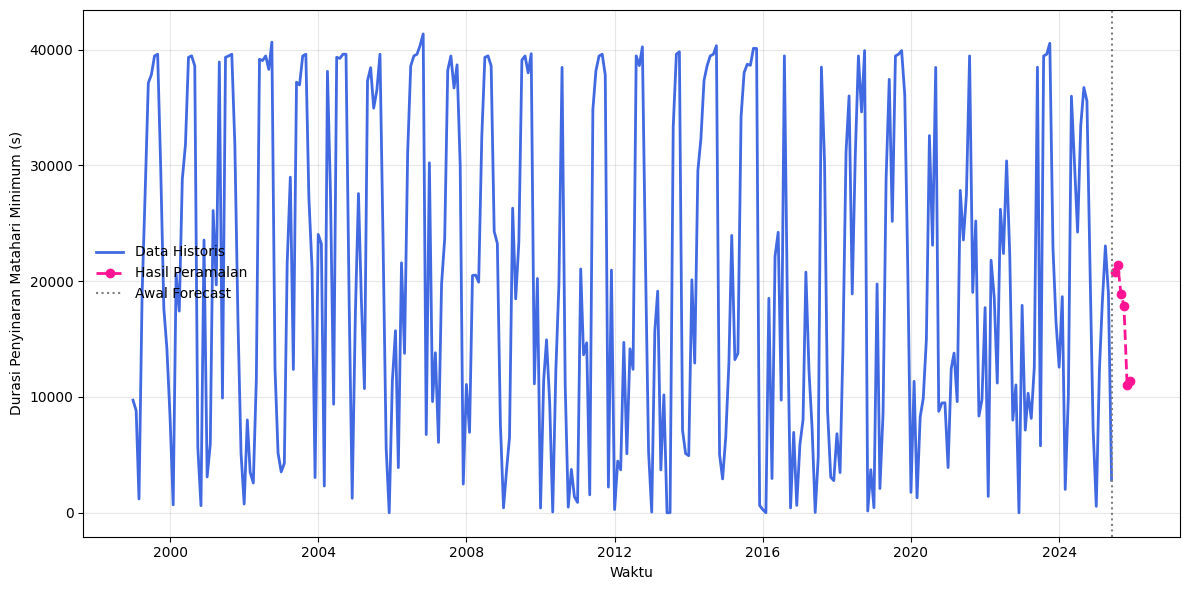

In [ ]:
# Visualisasi Hasil Peramalan
forecast_min = pd.DataFrame({
    'tanggal': dates_min,
    'prediksi': pred_min_future
})
forecast_min.set_index('tanggal', inplace = True)

historical_data_min = data_min[['DPM Minimum']].copy()
combined_min = pd.concat([historical_data_min, forecast_min.rename(columns = {'prediksi': 'DPM Minimum'})])

plt.figure(figsize = (12, 6))

plt.plot(
    historical_data_min.index,
    historical_data_min['DPM Minimum'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_min.index,
    forecast_min['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_data_min.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Minimum (s)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

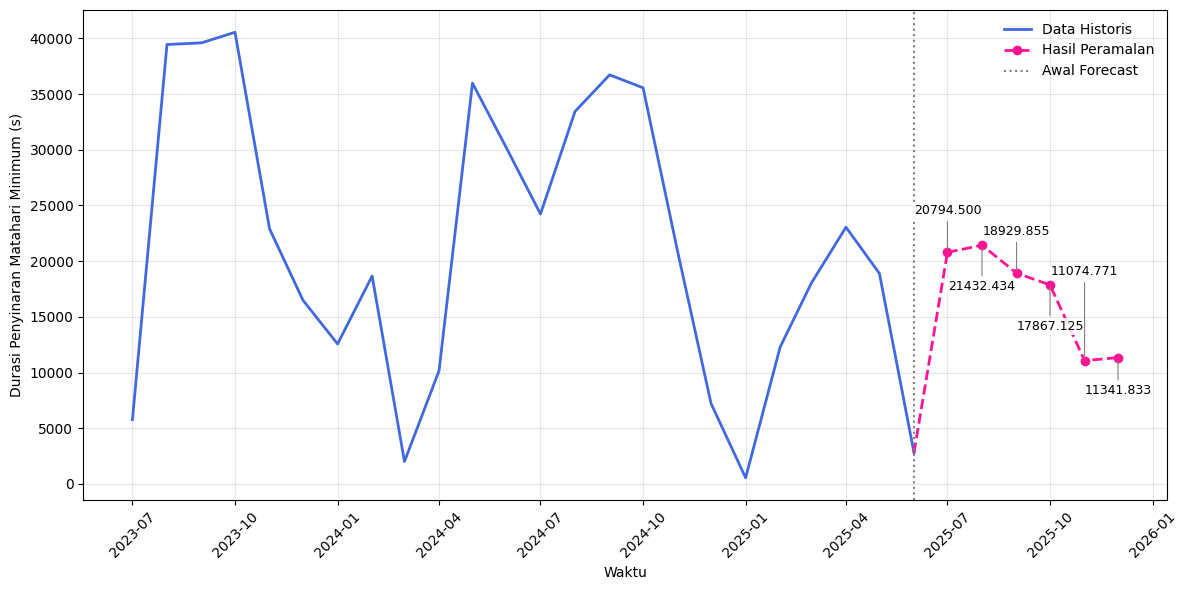

In [ ]:
# Visualisasi Hasil Peramalan
historical_tail_min = data_min[['DPM Minimum']].tail(24).copy()

forecast_min = pd.DataFrame({
    'tanggal': dates_min,
    'prediksi': pred_min_future
})
forecast_min.set_index('tanggal', inplace = True)

plt.figure(figsize = (12, 6))

plt.plot(
    historical_tail_min.index,
    historical_tail_min['DPM Minimum'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_min.index,
    forecast_min['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.plot(
    [historical_tail_min.index[-1], forecast_min.index[0]],
    [historical_tail_min['DPM Minimum'].iloc[-1], forecast_min['prediksi'].iloc[0]],
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.axvline(
    x = historical_tail_min.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

offsets = [
    (0, 30),
    (0, -30),
    (0, 30),
    (0, -30),
    (0, 64),
    (0, -24)
]

for (x, y), (dx, dy) in zip(zip(forecast_min.index, forecast_min['prediksi']), offsets):
    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = (dx, dy),
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.85, edgecolor = 'none', pad = 1.2),
        arrowprops = dict(
            arrowstyle = '-',
            color = 'gray',
            lw = 0.8
        )
    )

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Minimum (s)')
plt.xticks(rotation = 45)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# X

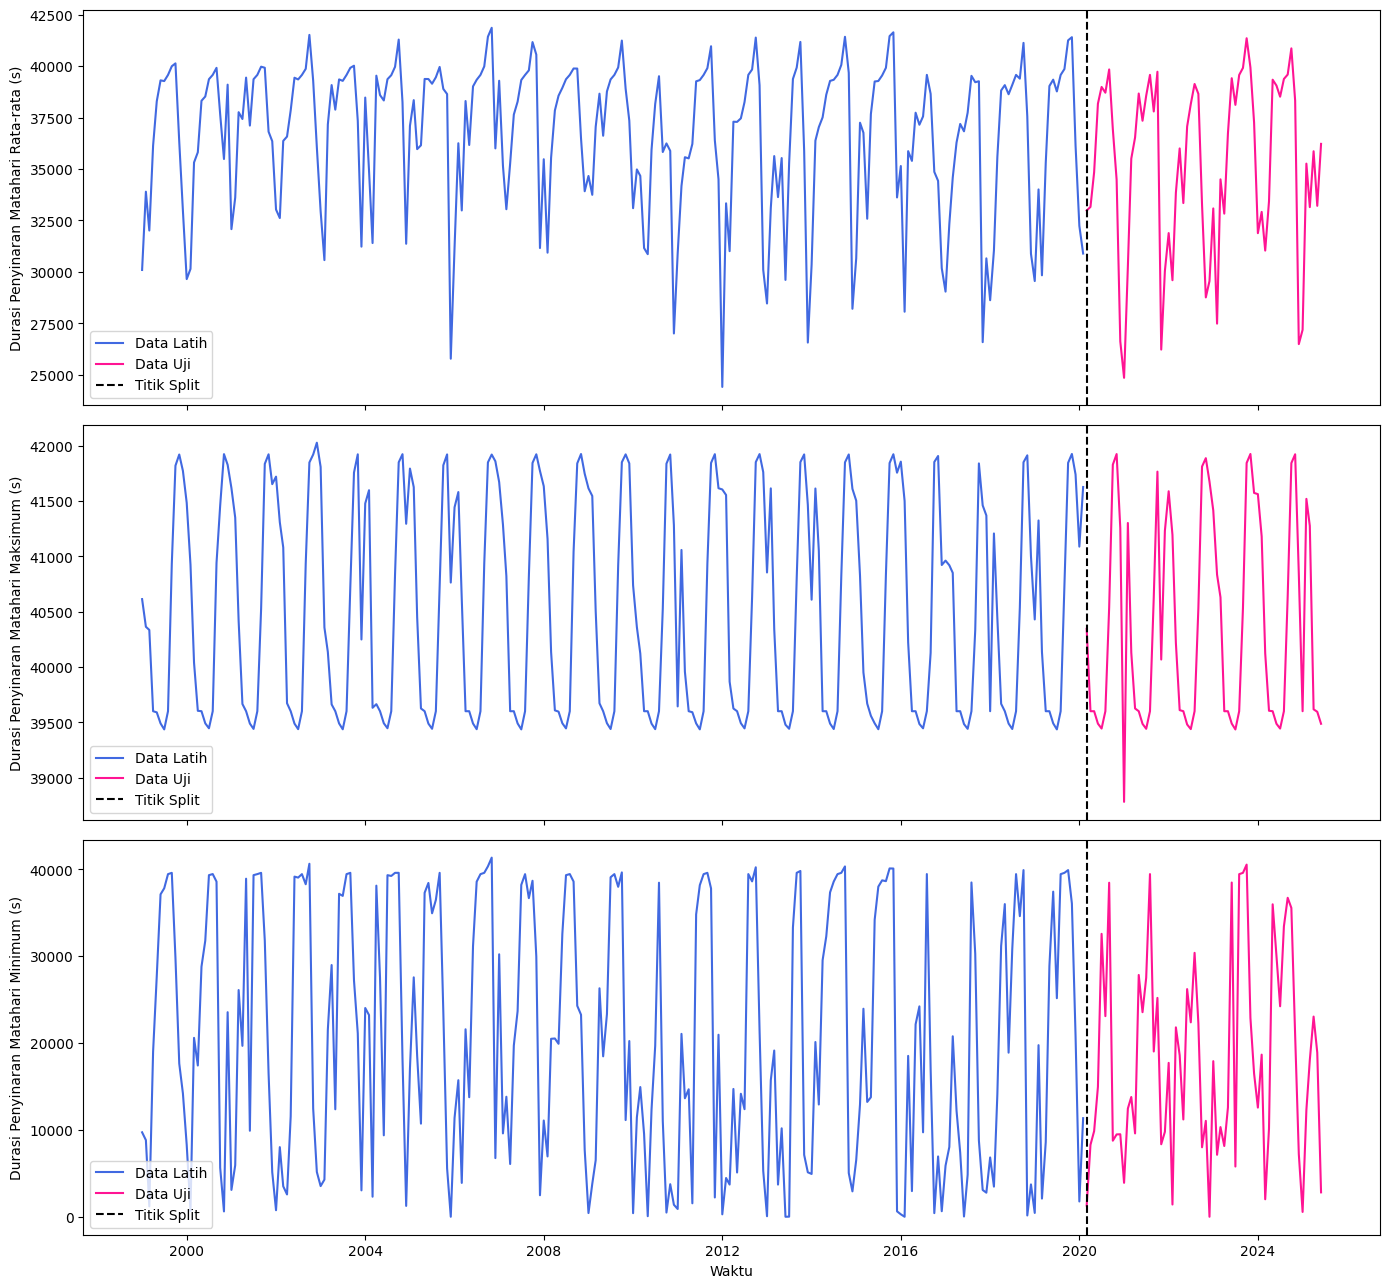

In [ ]:
# Visualisasi Split Data
split_index_mean = int(len(data_mean) * split_ratio)
split_index_max  = int(len(data_max) * split_ratio)
split_index_min  = int(len(data_min) * split_ratio)

fig, axes = plt.subplots(3, 1, figsize = (14, 13), sharex = True)

# Durasi Penyinaran Matahari Rata-rata
axes[0].plot(train_mean_original.index,
             train_mean_original.iloc[:, 0],
             label = "Data Latih",
             color = "royalblue")

axes[0].plot(test_mean_original.index,
             test_mean_original.iloc[:, 0],
             label = "Data Uji",
             color = "deeppink")

axes[0].axvline(x = data_mean.index[split_index_mean],
                linestyle = '--',
                color = 'black',
                label = "Titik Split")

axes[0].set_ylabel("Durasi Penyinaran Matahari Rata-rata (s)")
axes[0].legend()

# Durasi Penyinaran Matahari Maksimum
axes[1].plot(train_max_original.index,
             train_max_original.iloc[:, 0],
             label = "Data Latih",
             color = "royalblue")

axes[1].plot(test_max_original.index,
             test_max_original.iloc[:, 0],
             label = "Data Uji",
             color = "deeppink")

axes[1].axvline(x = data_max.index[split_index_max],
                linestyle = '--',
                color = 'black',
                label = "Titik Split")

axes[1].set_ylabel("Durasi Penyinaran Matahari Maksimum (s)")
axes[1].legend()

# Durasi Penyinaran Matahari Minimum
axes[2].plot(train_min_original.index,
             train_min_original.iloc[:, 0],
             label = "Data Latih",
             color = "royalblue")

axes[2].plot(test_min_original.index,
             test_min_original.iloc[:, 0],
             label = "Data Uji",
             color = "deeppink")

axes[2].axvline(x = data_min.index[split_index_min],
                linestyle = '--',
                color = 'black',
                label = "Titik Split")

axes[2].set_ylabel("Durasi Penyinaran Matahari Minimum (s)")
axes[2].set_xlabel("Waktu")
axes[2].legend()

plt.tight_layout()
plt.show()

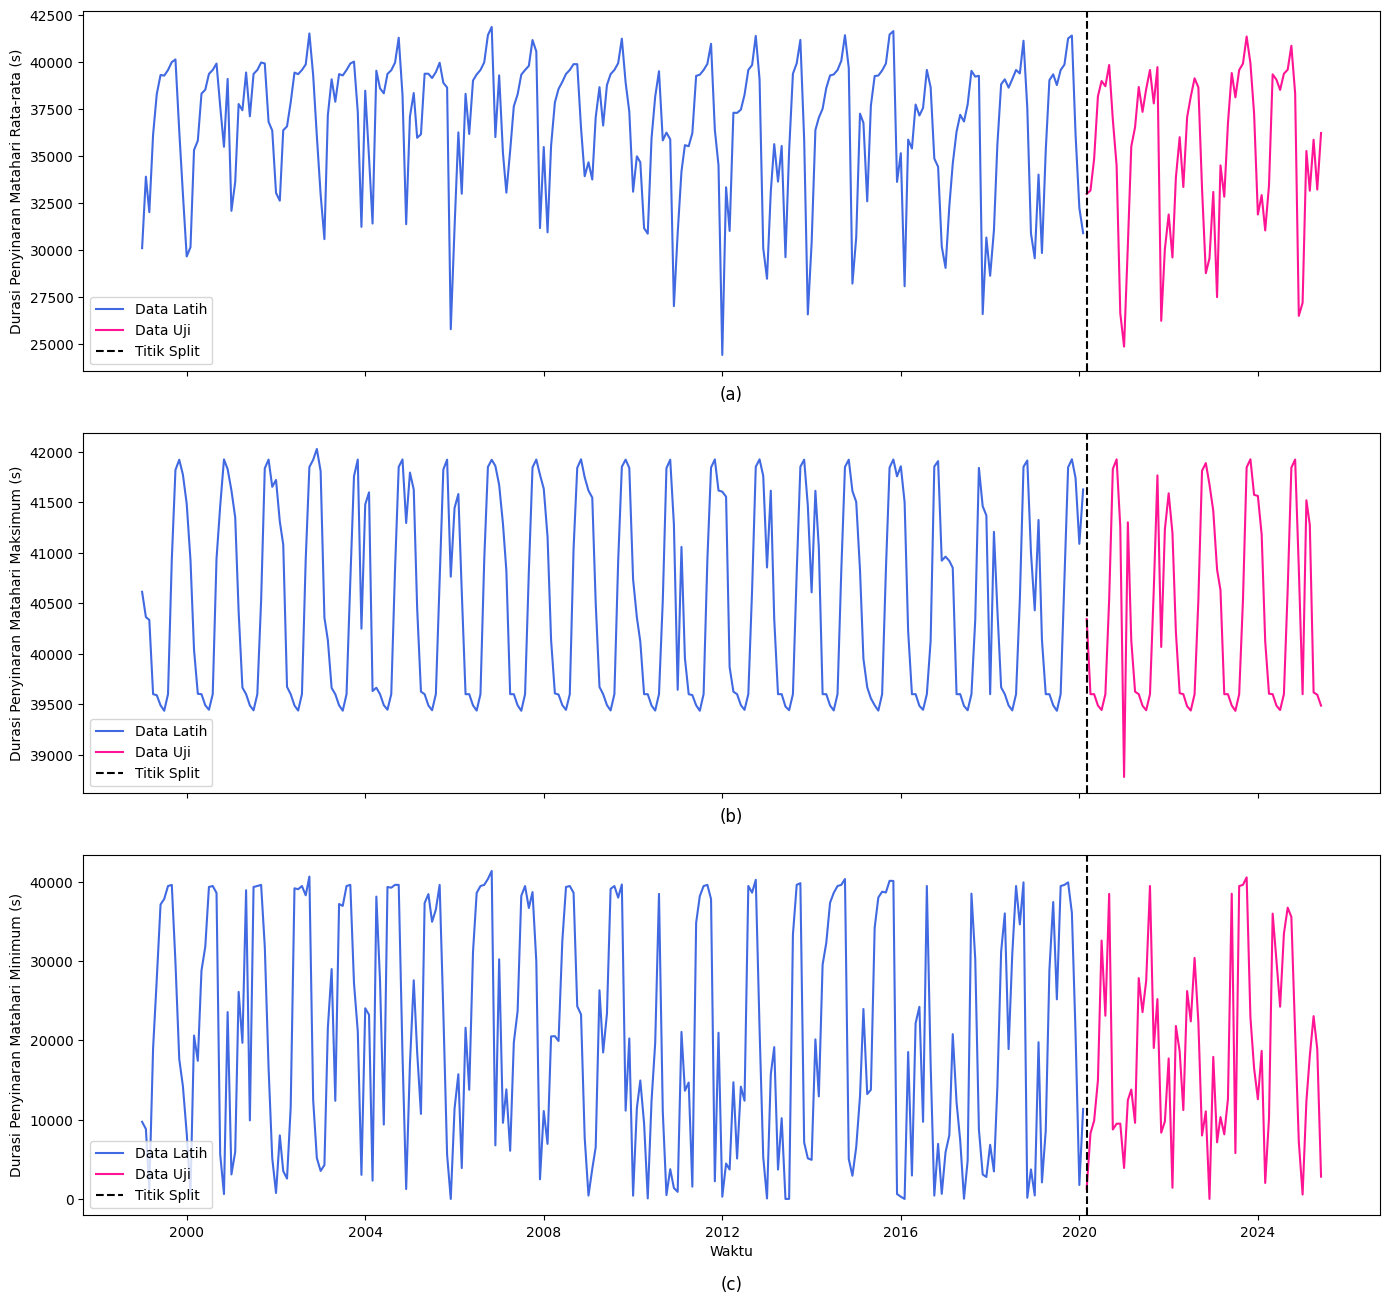

In [ ]:
# Visualisasi Split Data
split_index_mean = int(len(data_mean) * split_ratio)
split_index_max  = int(len(data_max) * split_ratio)
split_index_min  = int(len(data_min) * split_ratio)

fig, axes = plt.subplots(3, 1, figsize = (14, 13), sharex = True)

# Durasi Penyinaran Matahari Rata-rata
axes[0].plot(train_mean_original.index,
             train_mean_original.iloc[:, 0],
             label = "Data Latih",
             color = "royalblue")

axes[0].plot(test_mean_original.index,
             test_mean_original.iloc[:, 0],
             label = "Data Uji",
             color = "deeppink")

axes[0].axvline(x = data_mean.index[split_index_mean],
                linestyle = '--',
                color = 'black',
                label = "Titik Split")

axes[0].set_ylabel("Durasi Penyinaran Matahari Rata-rata (s)")
axes[0].legend()
axes[0].set_title("(a)", y = -0.10)

# Durasi Penyinaran Matahari Maksimum
axes[1].plot(train_max_original.index,
             train_max_original.iloc[:, 0],
             label = "Data Latih",
             color = "royalblue")

axes[1].plot(test_max_original.index,
             test_max_original.iloc[:, 0],
             label = "Data Uji",
             color = "deeppink")

axes[1].axvline(x = data_max.index[split_index_max],
                linestyle = '--',
                color = 'black',
                label = "Titik Split")

axes[1].set_ylabel("Durasi Penyinaran Matahari Maksimum (s)")
axes[1].legend()
axes[1].set_title("(b)", y = -0.10)

# Durasi Penyinaran Matahari Minimum
axes[2].plot(train_min_original.index,
             train_min_original.iloc[:, 0],
             label = "Data Latih",
             color = "royalblue")

axes[2].plot(test_min_original.index,
             test_min_original.iloc[:, 0],
             label = "Data Uji",
             color = "deeppink")

axes[2].axvline(x = data_min.index[split_index_min],
                linestyle = '--',
                color = 'black',
                label = "Titik Split")

axes[2].set_ylabel("Durasi Penyinaran Matahari Minimum (s)")
axes[2].set_xlabel("Waktu")
axes[2].legend()
axes[2].set_title("(c)", y = -0.23)

plt.tight_layout(h_pad = 2.6)
plt.show()